In [1]:
import sys 
import os 

sys.path.append(os.path.join('..', '..'))

In [2]:
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
import unicodedata
from urllib.parse import urlencode

from config.bairro_cleaning_config import MAPA_BAIRRO


In [3]:
data_dir = Path("../../data/base_de_dados_final/")
arquivo = data_dir / "base_sigesguarda_socioeconomica.csv"

In [4]:
caminho_imagens = Path("../../imagens")
os.makedirs(caminho_imagens, exist_ok=True)

In [5]:
df = pd.read_csv(arquivo, sep=";", encoding="latin1", dtype=str)

In [6]:
df.head()

,ATENDIMENTO_BAIRRO_NOME,FLAG_EQUIPAMENTO_URBANO,FLAG_FLAGRANTE,LOGRADOURO_NOME,NATUREZA1_DEFESA_CIVIL,NATUREZA1_DESCRICAO,NATUREZA2_DEFESA_CIVIL,NATUREZA2_DESCRICAO,NATUREZA3_DEFESA_CIVIL,NATUREZA3_DESCRICAO,...,pct_analfabetismo_15mais_estimado,domicilios_particulares_ocupados_estimado,sem_banheiro_sanitario_estimado,pct_sem_banheiro_sanitario_estimado,esgotamento_precario_estimado,pct_esgotamento_precario_estimado,sem_rede_geral_agua_estimado,pct_sem_rede_geral_agua_estimado,lixo_destino_inadequado_estimado,pct_lixo_destino_inadequado_estimado
0,cidade industrial,0,0,davi xavier da silva,0,alarmes,0,NaN,0,NaN,...,3.34,52161,47,0.09,1359,2.61,97,0.19,22,0.04
1,fazendinha,1,0,carlos klemtz,0,roubo,0,NaN,0,NaN,...,2.51,8980,3,0.04,104,1.16,6,0.07,2,0.02
2,uberaba,0,0,doutor joao de paula moura brito,0,animais,0,NaN,0,NaN,...,2.51,21881,23,0.11,1296,5.92,273,1.25,10,0.04
3,sitio cercado,0,0,edgard cavalcanti de albuquerque,0,animais,0,NaN,0,NaN,...,3.39,35174,35,0.1,331,0.94,97,0.28,3,0.01
4,tatuquara,1,0,carlos munhoz da rocha,0,alarmes,0,NaN,0,NaN,...,4.79,14960,25,0.17,1383,9.25,55,0.37,30,0.2


In [7]:
df.columns

Index(['ATENDIMENTO_BAIRRO_NOME', 'FLAG_EQUIPAMENTO_URBANO', 'FLAG_FLAGRANTE',
       'LOGRADOURO_NOME', 'NATUREZA1_DEFESA_CIVIL', 'NATUREZA1_DESCRICAO',
       'NATUREZA2_DEFESA_CIVIL', 'NATUREZA2_DESCRICAO',
       'NATUREZA3_DEFESA_CIVIL', 'NATUREZA3_DESCRICAO',
       'NATUREZA4_DEFESA_CIVIL', 'NATUREZA4_DESCRICAO',
       'NATUREZA5_DEFESA_CIVIL', 'NATUREZA5_DESCRICAO', 'OCORRENCIA_ANO',
       'OCORRENCIA_DIA_SEMANA', 'OCORRENCIA_MES', 'SECRETARIA_SIGLA',
       'SERVICO_NOME', 'NUMERO_PROTOCOLO_156', 'OCORRENCIA_DIA',
       'OCORRENCIA_HORA_HORA', 'OCORRENCIA_HORA_MINUTO', 'MADRUGADA', 'MANHA',
       'TARDE', 'NOITE', 'CRIME_VIOLENTO',
       'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL', 'ACIDENTE_TRANSITO',
       'ACIDENTE_NATURAL', 'CRIME_PATRIMONIAL', 'CRIME_ADMINISTRACAO_PUBLICA',
       'CRIME_HONRA_DISCRIMINACAO', 'CRIME_CRIANCA_ADOLESCENTE',
       'CRIME_FRAUDE_DOCUMENTAL', 'CRIME_DROGAS_SUBSTANCIAS',
       'CRIME_ORDEM_PUBLICA', 'RISCO_ESTRUTURAL',
       'EXPLOSIVOS_E_PR

## 1. Métricas de ocorrência

Antes de iniciarmos a análise dos dados, é necessário definir métricas que permitam comparar os bairros de forma equilibrada. Se utilizássemos apenas valores absolutos, isso poderia levar a interpretações equivocadas, já que bairros mais populosos tendem naturalmente a apresentar um número maior de ocorrências. Assim, além das contagens absolutas, serão utilizadas métricas normalizadas pela população, permitindo comparações mais adequadas entre bairros de diferentes tamanhos.

As métricas definidas para a análise são:

- Total de ocorrências: corresponde à contagem total de registros de ocorrências em cada bairro. Essa métrica será calculada a partir das colunas `CRIME_VIOLENTO`, `ATENDIMENTO_OPERACIONAL_ASSISTENCIAL`, `ACIDENTE_TRANSITO`, `ACIDENTE_NATURAL`, `CRIME_PATRIMONIAL`, `CRIME_ADMINISTRACAO_PUBLICA`, `CRIME_HONRA_DISCRIMINACAO`, `CRIME_CRIANCA_ADOLESCENTE`, `CRIME_FRAUDE_DOCUMENTAL`, `CRIME_DROGAS_SUBSTANCIAS`, `CRIME_ORDEM_PUBLICA`, `RISCO_ESTRUTURAL`, `EXPLOSIVOS_E_PRODUTOS_PERIGOSOS`, `PESSOAS_DESAPARECIDAS` e  `MATERIAIS_OBJETOS`. O objetivo é obter o número total de ocorrências registradas por bairro em cada período analisado;

- Taxa total por 10 mil habitantes: essa métrica será obtida dividindo o total de ocorrências estimado para um bairro pela população estimada desse bairro no respectivo ano, multiplicando o resultado por 10.000, permitindo que sejam comparados bairros de tamanhos diferentes;
  
- Total de ocorrências por tipo: representa a contagem absoluta de ocorrências para cada categoria específica de ocorrência;

- Taxa por tipo de ocorrência por 10 mil habitantes: para cada cateogira de ocorrência, será calculada uma taxa padronizada dividindo o total de ocorrências daquele tipo pela população estimada do bairro no respectivo ano e multiplicando o resultado por 10.000;

- Proporção de ocorrências por tipo: será utilizada para analisar a composição das ocorrências em cada bairro, calculando a razão entre o número de ocorrências de um determinado tipo e o total de ocorrências registradas no bairro.

### 1.1 Cálculo das métricas de ocorrência

Para a análise, será calculada o total de ocorrências registradas em cada um dos 75 bairros oficiais de Curitiba. Para isso, o dataframe será filtrado com base nas colunas que identificam o tipo de ocorrência. Em seguida, para cada bairro e para cada período analisado entre 2009 e 2026, será realizada a contagem do número de registros associados ao bairro.

In [8]:
colunas_tipo_ocorrencia = [
    "CRIME_VIOLENTO",
    "ATENDIMENTO_OPERACIONAL_ASSISTENCIAL",
    "ACIDENTE_TRANSITO",
    "ACIDENTE_NATURAL",
    "CRIME_PATRIMONIAL",
    "CRIME_ADMINISTRACAO_PUBLICA",
    "CRIME_HONRA_DISCRIMINACAO",
    "CRIME_CRIANCA_ADOLESCENTE",
    "CRIME_FRAUDE_DOCUMENTAL",
    "CRIME_DROGAS_SUBSTANCIAS",
    "CRIME_ORDEM_PUBLICA",
    "RISCO_ESTRUTURAL",
    "EXPLOSIVOS_E_PRODUTOS_PERIOGOSOS",
    "PESSOAS_DESAPARECIDAS",
    "MATERIAIS_OBJETOS",
]

In [9]:
df_metricas = df.copy()

In [10]:
for coluna in colunas_tipo_ocorrencia:
    df_metricas[coluna] = pd.to_numeric(
        df_metricas[coluna],
        errors="coerce"
    ).fillna(0).astype(int)

In [11]:
metricas_bairro_ano = (
    df_metricas
    .groupby(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"], as_index=False)
    .agg(
        total_ocorrencias=("ATENDIMENTO_BAIRRO_NOME", "size"),
        **{
            f"total_{coluna.lower()}": (coluna, "sum")
            for coluna in colunas_tipo_ocorrencia
        }
    )
)

In [12]:
metricas_bairro_ano["OCORRENCIA_ANO"] = pd.to_numeric(
    metricas_bairro_ano["OCORRENCIA_ANO"],
    errors="coerce"
).astype("Int64")

In [13]:
metricas_bairro_ano.head(3)

,ATENDIMENTO_BAIRRO_NOME,OCORRENCIA_ANO,total_ocorrencias,total_crime_violento,total_atendimento_operacional_assistencial,total_acidente_transito,total_acidente_natural,total_crime_patrimonial,total_crime_administracao_publica,total_crime_honra_discriminacao,total_crime_crianca_adolescente,total_crime_fraude_documental,total_crime_drogas_substancias,total_crime_ordem_publica,total_risco_estrutural,total_explosivos_e_produtos_periogosos,total_pessoas_desaparecidas,total_materiais_objetos
0,abranches,2009,124,5,28,2,26,30,0,0,0,0,1,39,2,1,0,0
1,abranches,2010,118,5,21,5,19,22,0,0,0,0,3,40,2,1,0,0
2,abranches,2011,85,5,20,2,21,17,0,0,0,0,3,11,6,1,0,0


### 1.2 Cálculo da taxa de métricas de ocorrência

Para normalizar os dados, vamos calcular:

$$
\frac{\text{total\_ocorrencias}}{\text{populacao\_estimado}} \times 10000
$$

In [14]:
df_metricas["OCORRENCIA_ANO"] = pd.to_numeric(
    df_metricas["OCORRENCIA_ANO"],
    errors="coerce"
).astype("Int64")

df_metricas["populacao_estimado"] = pd.to_numeric(
    df_metricas["populacao_estimado"],
    errors="coerce"
).astype("Int64")

In [15]:
populacao_bairro_ano = (
    df_metricas
    .groupby(
        ["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"],
        as_index=False
    )
    .agg(
        populacao_estimado=("populacao_estimado", "first")
    )
)

In [16]:
metricas_bairro_ano = metricas_bairro_ano.merge(
    populacao_bairro_ano,
    on=["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"],
    how="left",
    validate="one_to_one"
)

In [17]:
metricas_bairro_ano["taxa_total_ocorrencias_10k"] = (
    metricas_bairro_ano["total_ocorrencias"]
    / metricas_bairro_ano["populacao_estimado"]
    * 10_000
)

In [18]:
metricas_bairro_ano["taxa_total_ocorrencias_10k"] = (
    metricas_bairro_ano["taxa_total_ocorrencias_10k"]
    .round(2)
)

Agora, iremos calcular a taxa de ocorrências para todas as categorias de ocorrências criadas:

- `CRIME_VIOLENTO`;
- `ATENDIMENTO_OPERACIONAL_ASSISTENCIAL`;
- `ACIDENTE_TRANSITO`;
- `ACIDENTE_NATURAL`; 
- `CRIME_PATRIMONIAL`; 
- `CRIME_ADMINISTRACAO_PUBLICA`; 
- `CRIME_HONRA_DISCRIMINACAO`;
- `CRIME_CRIANCA_ADOLESCENTE`; 
- `CRIME_FRAUDE_DOCUMENTAL`; 
- `CRIME_DROGAS_SUBSTANCIAS`; 
- `CRIME_ORDEM_PUBLICA`; 
- `RISCO_ESTRUTURAL`; 
- `EXPLOSIVOS_E_PRODUTOS_PERIGOSOS`; 
- `PESSOAS_DESAPARECIDAS`;
- `MATERIAIS_OBJETOS`.

In [19]:
colunas_totais_tipo = [
    f"total_{coluna.lower()}"
    for coluna in colunas_tipo_ocorrencia
]

In [20]:
for coluna in colunas_totais_tipo:
    nome_taxa = coluna.replace("total_", "taxa_") + "_10k"

    metricas_bairro_ano[nome_taxa] = (
        metricas_bairro_ano[coluna]
        / metricas_bairro_ano["populacao_estimado"]
        * 10_000
    )

In [21]:
colunas_taxas = [
    coluna for coluna in metricas_bairro_ano.columns
    if coluna.startswith("taxa_") and coluna.endswith("_10k")
]


In [22]:
metricas_bairro_ano[colunas_taxas] = metricas_bairro_ano[colunas_taxas].round(2)

In [23]:
metricas_bairro_ano.head(3)

,ATENDIMENTO_BAIRRO_NOME,OCORRENCIA_ANO,total_ocorrencias,total_crime_violento,total_atendimento_operacional_assistencial,total_acidente_transito,total_acidente_natural,total_crime_patrimonial,total_crime_administracao_publica,total_crime_honra_discriminacao,...,taxa_crime_administracao_publica_10k,taxa_crime_honra_discriminacao_10k,taxa_crime_crianca_adolescente_10k,taxa_crime_fraude_documental_10k,taxa_crime_drogas_substancias_10k,taxa_crime_ordem_publica_10k,taxa_risco_estrutural_10k,taxa_explosivos_e_produtos_periogosos_10k,taxa_pessoas_desaparecidas_10k,taxa_materiais_objetos_10k
0,abranches,2009,124,5,28,2,26,30,0,0,...,0.0,0.0,0.0,0.0,0.76,29.81,1.53,0.76,0.0,0.0
1,abranches,2010,118,5,21,5,19,22,0,0,...,0.0,0.0,0.0,0.0,2.28,30.42,1.52,0.76,0.0,0.0
2,abranches,2011,85,5,20,2,21,17,0,0,...,0.0,0.0,0.0,0.0,2.27,8.32,4.54,0.76,0.0,0.0


In [24]:
metricas_bairro_ano.columns

Index(['ATENDIMENTO_BAIRRO_NOME', 'OCORRENCIA_ANO', 'total_ocorrencias',
       'total_crime_violento', 'total_atendimento_operacional_assistencial',
       'total_acidente_transito', 'total_acidente_natural',
       'total_crime_patrimonial', 'total_crime_administracao_publica',
       'total_crime_honra_discriminacao', 'total_crime_crianca_adolescente',
       'total_crime_fraude_documental', 'total_crime_drogas_substancias',
       'total_crime_ordem_publica', 'total_risco_estrutural',
       'total_explosivos_e_produtos_periogosos', 'total_pessoas_desaparecidas',
       'total_materiais_objetos', 'populacao_estimado',
       'taxa_total_ocorrencias_10k', 'taxa_crime_violento_10k',
       'taxa_atendimento_operacional_assistencial_10k',
       'taxa_acidente_transito_10k', 'taxa_acidente_natural_10k',
       'taxa_crime_patrimonial_10k', 'taxa_crime_administracao_publica_10k',
       'taxa_crime_honra_discriminacao_10k',
       'taxa_crime_crianca_adolescente_10k',
       'taxa_crim

### 1.3 Total de ocorrências atendidas pela Guarda Municipal em Curitiba para cada 10 mil habitantes

Nessa etapa, calcularemos a taxa anual de ocorrências atendidas ela Guarda municipal para cada 10 mil habitantes. Para isso, agregaremos os dados por `OCORRENCIA_ANO`, somando o total de ocorrências a população estimada e os totais de cada tipo de ocorrência.

Após essa agregação, a taxa geral de ocorrências foi calculada dividindo o número total de registros pela população estimada de Curitiba em cada ano e multiplicando o resultado por 10 mil.

In [25]:
colunas_totais_tipo = [
    coluna for coluna in metricas_bairro_ano.columns 
    if coluna.startswith("total_")
    and coluna not in ["total_ocorrencias"]
]

agregacoes_curitiba = {
    "total_ocorrencias": ("total_ocorrencias", "sum"),
    "populacao_estimado": ("populacao_estimado", "sum"),
}

In [26]:
for coluna in colunas_totais_tipo: 
    agregacoes_curitiba[coluna] = (coluna, "sum")

In [27]:
serie_curitiba_10k = (
    metricas_bairro_ano
    .groupby("OCORRENCIA_ANO", as_index=False)
    .agg(**agregacoes_curitiba)
)

serie_curitiba_10k["OCORRENCIA_ANO"] = (
    serie_curitiba_10k["OCORRENCIA_ANO"]
    .astype(int)
)

serie_curitiba_10k["taxa_total_ocorrencias_10k"] = (
    serie_curitiba_10k["total_ocorrencias"]
    / serie_curitiba_10k["populacao_estimado"]
    * 10_000
)

for coluna in colunas_totais_tipo:
    nome_taxa = coluna.replace("total_", "taxa_") + "_10k"

    serie_curitiba_10k[nome_taxa] = (
        serie_curitiba_10k[coluna]
        / serie_curitiba_10k["populacao_estimado"]
        * 10_000
    )

In [28]:
colunas_taxa = [
    coluna for coluna in serie_curitiba_10k.columns
    if coluna.startswith("taxa_")
]

In [29]:
serie_curitiba_10k[colunas_taxa] = (
    serie_curitiba_10k[colunas_taxa]
    .round(2)
)

In [30]:
serie_curitiba_10k.head(3)

,OCORRENCIA_ANO,total_ocorrencias,populacao_estimado,total_crime_violento,total_atendimento_operacional_assistencial,total_acidente_transito,total_acidente_natural,total_crime_patrimonial,total_crime_administracao_publica,total_crime_honra_discriminacao,...,taxa_crime_administracao_publica_10k,taxa_crime_honra_discriminacao_10k,taxa_crime_crianca_adolescente_10k,taxa_crime_fraude_documental_10k,taxa_crime_drogas_substancias_10k,taxa_crime_ordem_publica_10k,taxa_risco_estrutural_10k,taxa_explosivos_e_produtos_periogosos_10k,taxa_pessoas_desaparecidas_10k,taxa_materiais_objetos_10k
0,2009,24773,1741667,1651,8061,717,3026,4610,149,7,...,0.86,0.04,0.11,0.45,4.76,35.17,1.88,1.44,0.36,0.21
1,2010,22329,1743840,1685,6760,832,2500,4033,184,3,...,1.06,0.02,0.14,0.22,7.09,29.81,1.36,1.51,0.25,0.34
2,2011,21308,1745527,1967,7436,1006,2579,4441,175,8,...,1.0,0.05,0.08,0.32,8.92,9.3,1.87,1.54,0.35,0.42


In [31]:
serie_curitiba_10k_plot = (
    serie_curitiba_10k[
        serie_curitiba_10k["OCORRENCIA_ANO"] < 2026
    ]
    .copy()
)

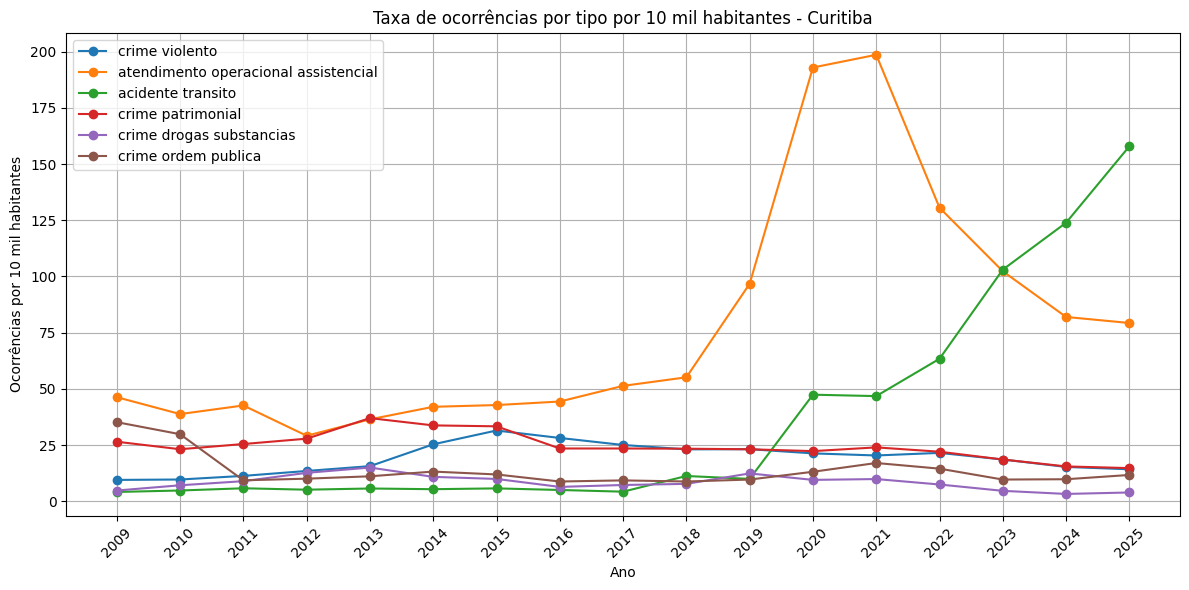

In [32]:
colunas_plot = [
    "taxa_crime_violento_10k",
    "taxa_atendimento_operacional_assistencial_10k",
    "taxa_acidente_transito_10k",
    "taxa_crime_patrimonial_10k",
    "taxa_crime_drogas_substancias_10k",
    "taxa_crime_ordem_publica_10k",
]

plt.figure(figsize=(12, 6))

for coluna in colunas_plot:
    plt.plot(
        serie_curitiba_10k_plot["OCORRENCIA_ANO"],
        serie_curitiba_10k_plot[coluna],
        marker="o",
        label=coluna.replace("taxa_", "").replace("_10k", "").replace("_", " ")
    )

plt.title("Taxa de ocorrências por tipo por 10 mil habitantes - Curitiba")
plt.xlabel("Ano")
plt.ylabel("Ocorrências por 10 mil habitantes")
plt.xticks(
    serie_curitiba_10k_plot["OCORRENCIA_ANO"],
    serie_curitiba_10k_plot["OCORRENCIA_ANO"].astype(int),
    rotation=45
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    caminho_imagens / "taxa_ocorrencias_tipo_curitiba.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 1.4 Aumento da taxa de ocorrências relacionados a crimes violentos para 10 mil habitantes por ano

Avaliaremos quais bairros apresentam maior crescimento na taxa de crimes violentos ao longo dos anos. Para isso, criaremos um dataframe com:

- `ATENDIMENTO_BAIRRO_NOME`;
- `OCORRENCIA_ANO`;
- `total_crime_violento`;
- `populacao_estimado`;
- `taxa_crime_violento_10k`.

Os dados serão ordenados por bairro e ano para permitir o cálculo da variação anual da taxa de crimes violentos em cada bairro. Essa variação será calculada pela diferença entre a taxa observada em um ano e a taxa observada no ano anterior:

$$
\Delta T_{i, t} = T_{i,t} - T_{i, t - 1}
$$

sendo $T_{i, t}$ a taxa de crimes violentos por 10 mil habitantes do bairro $i$ no ano $t$. 

Em seguida, será calculado o aumento médio anual da taxa de crimes violentos para cada bairro:

$$
\bar{\Delta T_{i}} = \frac{1}{n - 1}\sum_{t = 2}^{n_{i}}\Delta T_{i, t}
$$

In [33]:
violencia_bairro_ano = (
    metricas_bairro_ano[
        [
            "ATENDIMENTO_BAIRRO_NOME",
            "OCORRENCIA_ANO",
            "total_crime_violento",
            "populacao_estimado",
            "taxa_crime_violento_10k"
        ]
    ]
    .copy()
)

In [34]:
violencia_bairro_ano["OCORRENCIA_ANO"] = (
    violencia_bairro_ano["OCORRENCIA_ANO"]
    .astype(int)
)

In [35]:
violencia_bairro_ano = violencia_bairro_ano.sort_values(
    ["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"]
)

In [36]:
violencia_bairro_ano["variacao_anual_violencia_10k"] = (
    violencia_bairro_ano 
    .groupby("ATENDIMENTO_BAIRRO_NOME")["taxa_crime_violento_10k"]
    .diff()
)

In [37]:
aumento_medio_anual_violencia = (
    violencia_bairro_ano
    .dropna(subset=["variacao_anual_violencia_10k"])
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        aumento_medio_anual_violencia_10k=(
            "variacao_anual_violencia_10k",
            "mean"
        ),
        taxa_inicial_violencia_10k=(
            "taxa_crime_violento_10k",
            "first"
        ),
        taxa_final_violencia_10k=(
            "taxa_crime_violento_10k",
            "last"
        ),
        anos_observados=(
            "OCORRENCIA_ANO",
            "nunique"
        )
    )
)

In [38]:
violencia_bairro_ano = (
    violencia_bairro_ano[
        violencia_bairro_ano["OCORRENCIA_ANO"] < 2026
    ]
    .copy()
)

In [39]:
top10_aumento_medio_anual_violencia = (
    aumento_medio_anual_violencia
    .sort_values(
        "aumento_medio_anual_violencia_10k",
        ascending=False
    )
    .head(10)
)

In [40]:
top10_aumento_medio_anual_violencia

,ATENDIMENTO_BAIRRO_NOME,aumento_medio_anual_violencia_10k,taxa_inicial_violencia_10k,taxa_final_violencia_10k,anos_observados
38,jardim botanico,1.084118,34.75,49.61,17
52,prado velho,0.879412,13.34,33.02,17
63,sao miguel,0.467059,6.29,12.28,17
0,abranches,0.434706,3.8,11.21,17
34,guabirotuba,0.354706,0.88,8.65,17
68,tatuquara,0.309412,1.72,6.8,17
66,taboao,0.279412,23.56,37.2,17
25,cascatinha,0.272353,0.0,4.63,17
22,campo do santana,0.222353,0.74,5.32,17
11,batel,0.178824,6.49,10.4,17


Os cinco bairros com maior aumento médio anual da taxa de crimes violentos por 10 mil habitantes foram:

- Jardim Botânico;
- Prado Velho;
- São Miguel;
- Abranches;
- Guabirotuba.

O Jardim Botânico apresentou o maior crescimento médio anual, passando de 34.75 para 49.61 crimes violentos por 10 mil habitantes no período analisado.

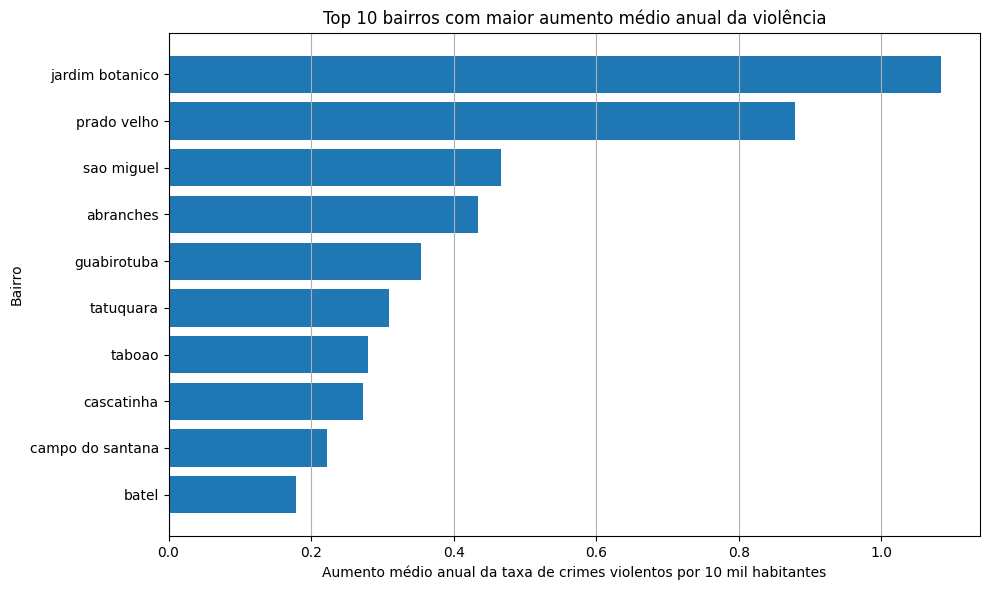

In [41]:
dados_plot = top10_aumento_medio_anual_violencia.sort_values(
    "aumento_medio_anual_violencia_10k",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    dados_plot["ATENDIMENTO_BAIRRO_NOME"],
    dados_plot["aumento_medio_anual_violencia_10k"]
)

plt.title("Top 10 bairros com maior aumento médio anual da violência")
plt.xlabel("Aumento médio anual da taxa de crimes violentos por 10 mil habitantes")
plt.ylabel("Bairro")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [42]:
bairros_top10 = top10_aumento_medio_anual_violencia[
    "ATENDIMENTO_BAIRRO_NOME"
].unique()

serie_top10 = (
    violencia_bairro_ano[
        violencia_bairro_ano["ATENDIMENTO_BAIRRO_NOME"].isin(bairros_top10)
    ]
    .copy()
    .sort_values(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"])
)

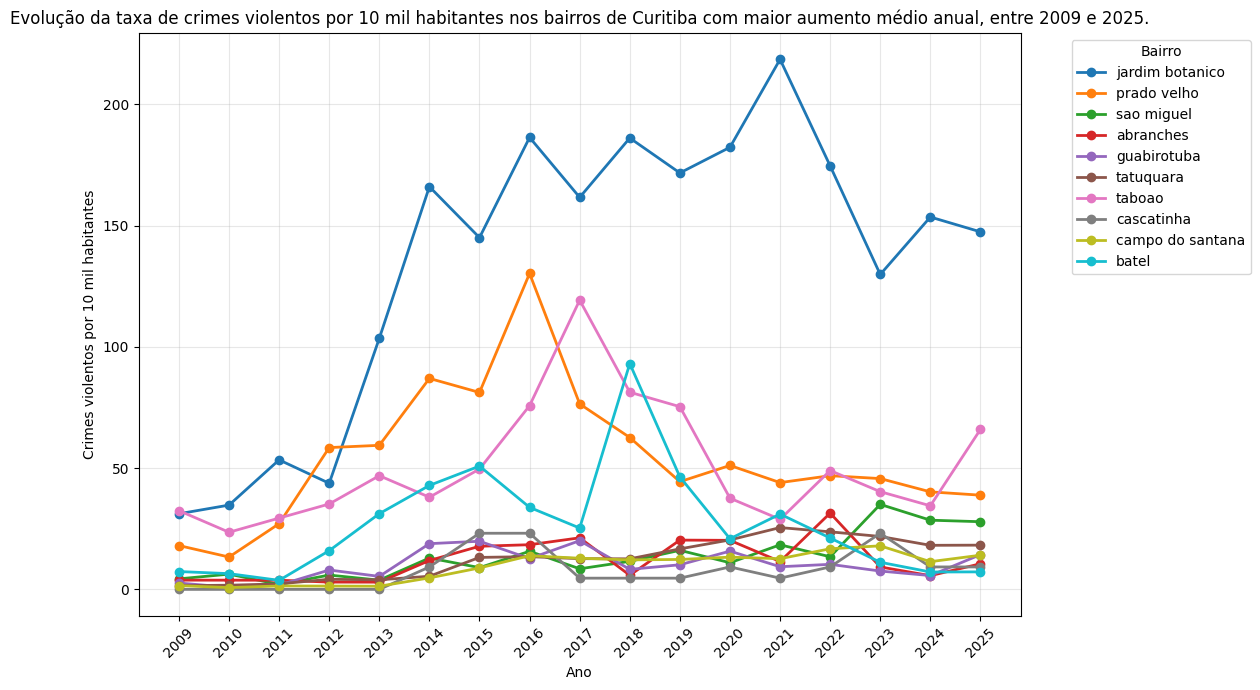

In [43]:
plt.figure(figsize=(12, 7))

for bairro in bairros_top10:
    dados_bairro = serie_top10[
        serie_top10["ATENDIMENTO_BAIRRO_NOME"] == bairro
    ]

    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro["taxa_crime_violento_10k"],
        marker="o",
        linewidth=2,
        label=bairro
    )

plt.xlabel("Ano")
plt.ylabel("Crimes violentos por 10 mil habitantes")
plt.title("Evolução da taxa de crimes violentos por 10 mil habitantes nos bairros de Curitiba com maior aumento médio anual, entre 2009 e 2025.")
plt.legend(title="Bairro", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.xticks(sorted(serie_top10["OCORRENCIA_ANO"].unique()), rotation=45)
plt.tight_layout()
plt.savefig(
    caminho_imagens / "serie_temporal_taxa_de_crimes_violentos_aumento_medio_anual.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


O bairro Jardim Botânico apresentou maior taxa de crescimento ao longo de quase toda a série, com crescimento expressivo entre 2012 e 2021. Os bairros Prado Velho e Taboão também apresentam aumentos relevantes, embora com maior variação entre os anos. No bairro Batel, houve um pico esporático de casos de ocorrências relacionadas a crimes violentos no ano de 2018.

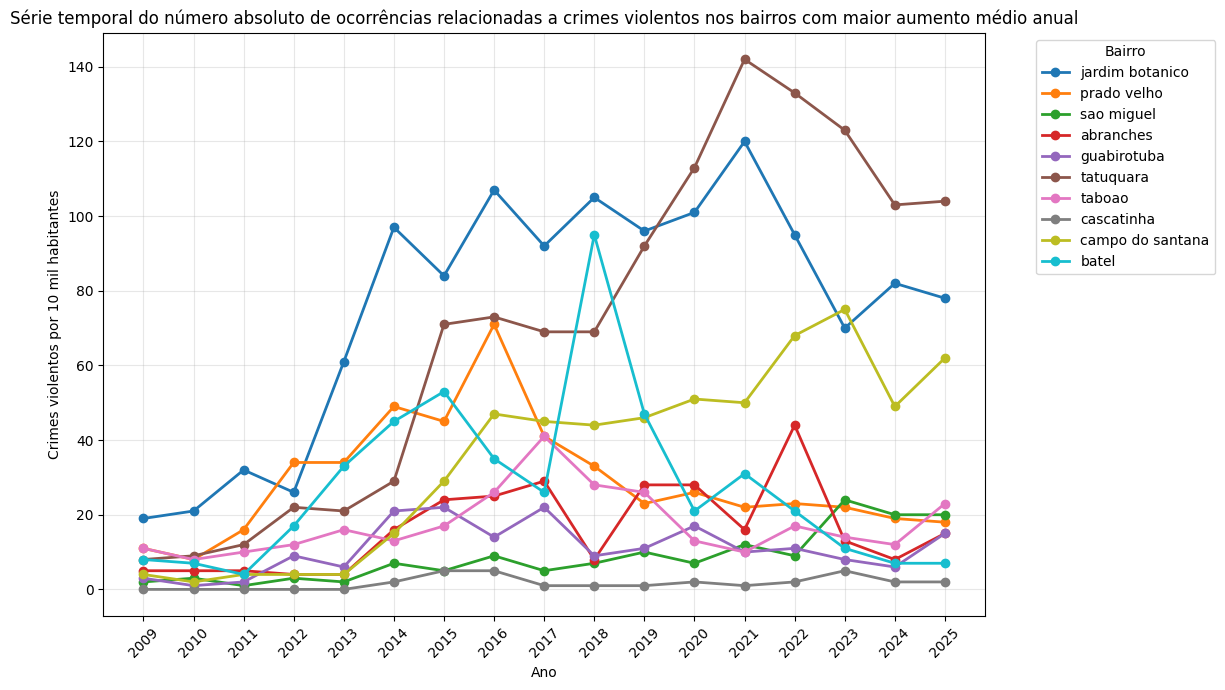

In [44]:
plt.figure(figsize=(12, 7))

for bairro in bairros_top10:
    dados_bairro = serie_top10[
        serie_top10["ATENDIMENTO_BAIRRO_NOME"] == bairro
    ]

    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro["total_crime_violento"],
        marker="o",
        linewidth=2,
        label=bairro
    )

plt.xlabel("Ano")
plt.ylabel("Crimes violentos por 10 mil habitantes")
plt.title("Série temporal do número absoluto de ocorrências relacionadas a crimes violentos nos bairros com maior aumento médio anual")
plt.legend(title="Bairro", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.xticks(sorted(serie_top10["OCORRENCIA_ANO"].unique()), rotation=45)
plt.tight_layout()
plt.show()


### 1.5  Aumento de ocorrências relacionados a drogas / substâncias lícitas para 10 mil habitantes por ano

Assim como feito para as ocorrências relacionadas a violência, faremos para ocorrências relacionadas a drogas / substâncias lícitas para cada 10 mil habitantes por ano. Para isso, criaremos um dataframe com:

- `ATENDIMENTO_BAIRRO_NOME`;
- `OCORRENCIA_ANO`;
- `total_crime_drogas_substancias`;
- `populacao_estimado`;
- `taxa_crime_drogas_substancias_10k`.

Da mesma forma, os dados serão ordenados por bairro e ano para permitir o cálculo da variação anual da taxa de crimes violentos em cada bairro. Essa variação será calculada pela diferença entre a taxa observada em um ano e a taxa observada no ano anterior:

$$
\Delta T_{i, t} = T_{i,t} - T_{i, t - 1}
$$

sendo $T_{i, t}$ a taxa de ocorrências relacionadas a drogas / substâncias lícitas por 10 mil habitantes do bairro $i$ no ano $t$. 

Em seguida, será calculado o aumento médio anual da taxa de ocorrências relacionadas a drogas / substâncias lícitas para cada bairro:

$$
\bar{\Delta T_{i}} = \frac{1}{n - 1}\sum_{t = 2}^{n_{i}}\Delta T_{i, t}
$$


In [45]:
drogas_bairro_ano = (
    metricas_bairro_ano[
        [
            "ATENDIMENTO_BAIRRO_NOME",
            "OCORRENCIA_ANO",
            "total_crime_drogas_substancias",
            "populacao_estimado",
            "taxa_crime_drogas_substancias_10k"
        ]
    ]
    .copy()
)

In [46]:
drogas_bairro_ano["OCORRENCIA_ANO"] = (
    drogas_bairro_ano["OCORRENCIA_ANO"]
    .astype(int)
)

In [47]:
drogas_bairro_ano = (
    drogas_bairro_ano[
        drogas_bairro_ano["OCORRENCIA_ANO"] < 2026
    ]
    .copy()
)

In [48]:
drogas_bairro_ano = drogas_bairro_ano.sort_values(
    ["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"]
)

In [49]:
drogas_bairro_ano["variacao_anual_drogas_substancias_10k"] = (
    drogas_bairro_ano
    .groupby("ATENDIMENTO_BAIRRO_NOME")["taxa_crime_drogas_substancias_10k"]
    .diff()
)

In [50]:
aumento_medio_anual_drogas_substancias = (
    drogas_bairro_ano
    .dropna(subset=["variacao_anual_drogas_substancias_10k"])
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        aumento_medio_anual_drogas_substancias_10k=(
            "variacao_anual_drogas_substancias_10k",
            "mean"
        ),
        taxa_inicial_drogas_substancias_10k=(
            "taxa_crime_drogas_substancias_10k",
            "first"
        ),
        taxa_final_drogas_substancias_10k=(
            "taxa_crime_drogas_substancias_10k",
            "last"
        ),
        anos_observados=(
            "OCORRENCIA_ANO",
            "nunique"
        )
    )
)

In [51]:
top10_aumento_medio_anual_drogas_substancias = (
    aumento_medio_anual_drogas_substancias
    .sort_values(
        "aumento_medio_anual_drogas_substancias_10k",
        ascending=False
    )
    .head(10)
)

In [52]:
top10_aumento_medio_anual_drogas_substancias

,ATENDIMENTO_BAIRRO_NOME,aumento_medio_anual_drogas_substancias_10k,taxa_inicial_drogas_substancias_10k,taxa_final_drogas_substancias_10k,anos_observados
60,sao francisco,3.0525,330.81,209.6,16
52,prado velho,1.07875,1.67,17.26,16
48,parolin,0.72125,6.97,11.54,16
73,vista alegre,0.585625,3.6,10.27,16
64,seminario,0.484375,2.92,9.19,16
37,hugo lange,0.428125,2.96,6.85,16
39,jardim das americas,0.2925,2.62,5.33,16
11,batel,0.265,1.85,5.16,16
0,abranches,0.216875,2.28,4.23,16
34,guabirotuba,0.179375,5.27,2.87,16


O resultado da exploração indica que o bairro São Francisco apresenta o maior aumento médio anual. Apesar disso, a taixa final é menor que a inicial, o que indica uma forte oscilação ao longo da série.

Já os bairros Prado Velho, Vista Alegre, Seminário e Batel apresentam crescimento mais claro, pois a taxa final é maior que a taxa inicial.

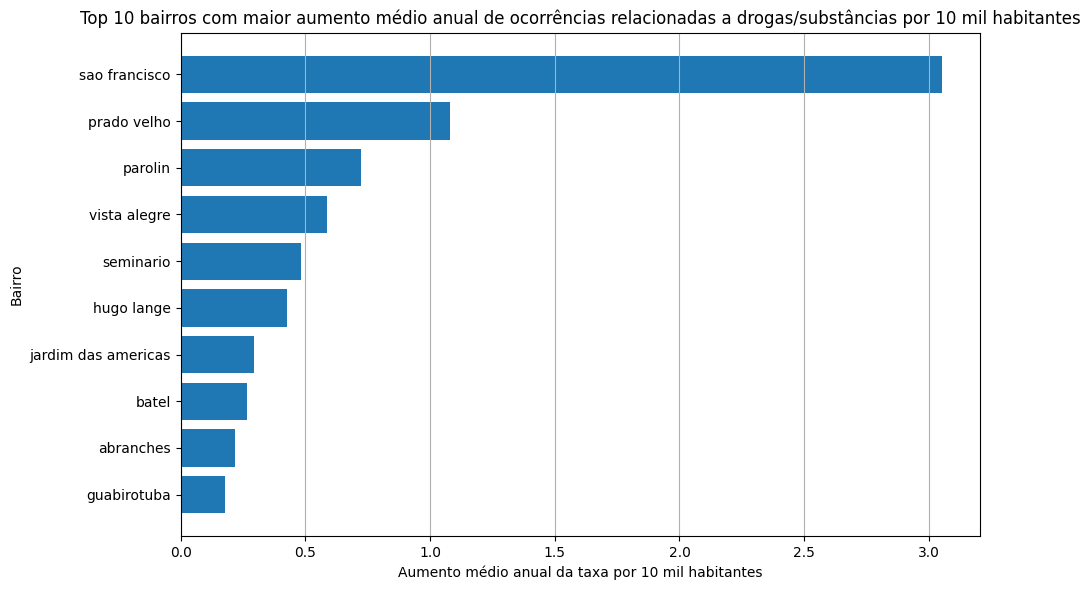

In [53]:
dados_plot = top10_aumento_medio_anual_drogas_substancias.sort_values(
    "aumento_medio_anual_drogas_substancias_10k",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    dados_plot["ATENDIMENTO_BAIRRO_NOME"],
    dados_plot["aumento_medio_anual_drogas_substancias_10k"]
)

plt.title("Top 10 bairros com maior aumento médio anual de ocorrências relacionadas a drogas/substâncias por 10 mil habitantes")
plt.xlabel("Aumento médio anual da taxa por 10 mil habitantes")
plt.ylabel("Bairro")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [54]:
bairros_top10 = top10_aumento_medio_anual_drogas_substancias[
    "ATENDIMENTO_BAIRRO_NOME"
  ].unique()

serie_top10 = (
    drogas_bairro_ano[
        drogas_bairro_ano["ATENDIMENTO_BAIRRO_NOME"].isin(bairros_top10)
    ]
    .copy()
    .sort_values(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"])
)

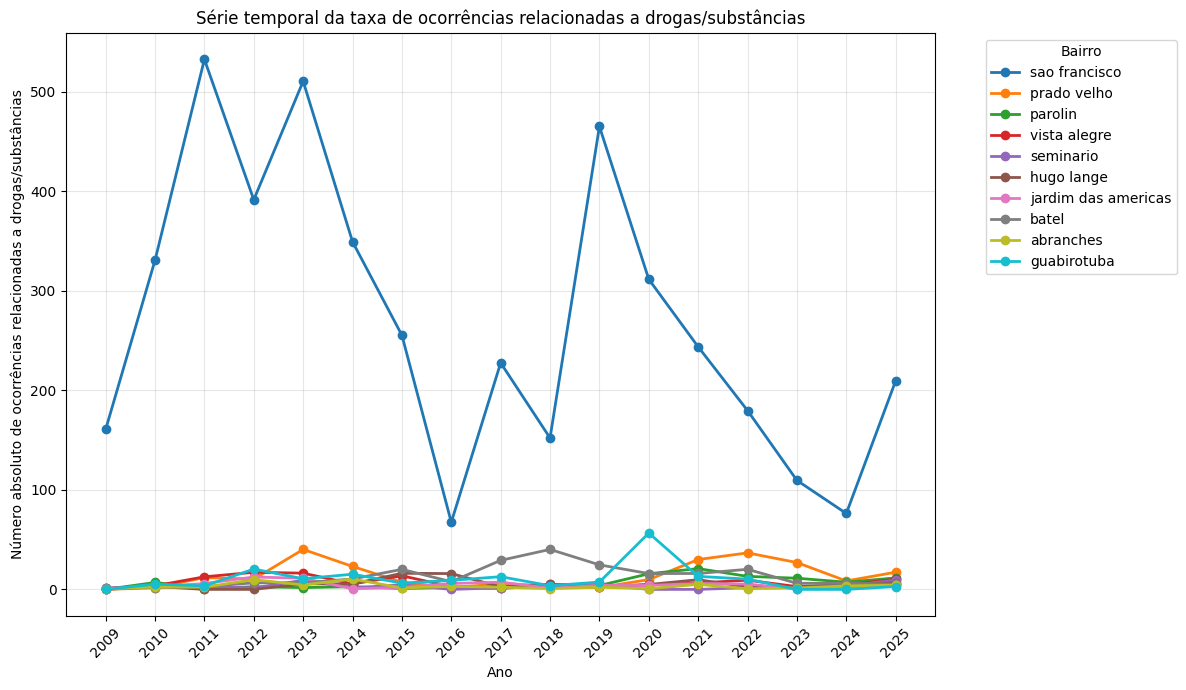

In [55]:
plt.figure(figsize=(12, 7))

for bairro in bairros_top10:
    dados_bairro = serie_top10[
        serie_top10["ATENDIMENTO_BAIRRO_NOME"] == bairro
    ]

    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro["taxa_crime_drogas_substancias_10k"],
        marker="o",
        linewidth=2,
        label=bairro
    )

plt.xlabel("Ano")
plt.ylabel("Número absoluto de ocorrências relacionadas a drogas/substâncias")
plt.title("Série temporal da taxa de ocorrências relacionadas a drogas/substâncias")
plt.legend(title="Bairro", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.xticks(sorted(serie_top10["OCORRENCIA_ANO"].unique()), rotation=45)
plt.tight_layout()
plt.savefig(
    caminho_imagens / "serie_temporal_taxa_de_drogas_aumento_medio_anual.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Como visto no dataframe, o bairro São Francisco possi uma grande oscilação, com ponto de máximo em 2011 e ponto de mínimo em 2016, seguido de um novo pico em 2020 e uma grande baixa em 2024.

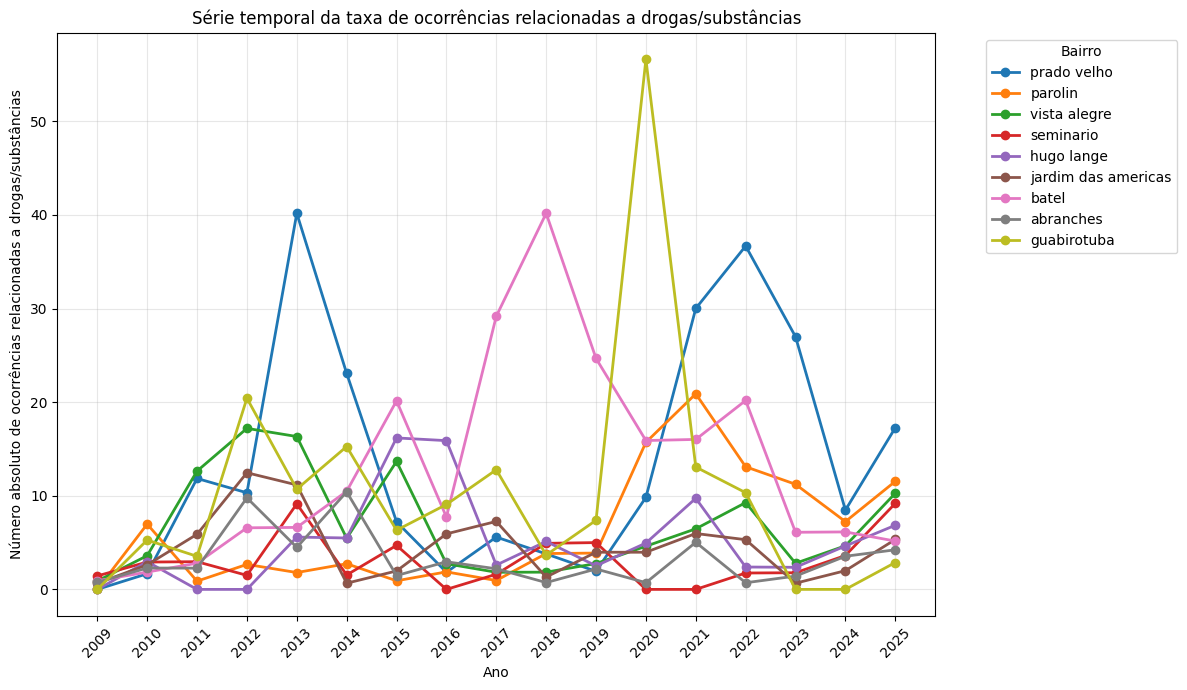

In [56]:
plt.figure(figsize=(12, 7))

for bairro in bairros_top10:
    if bairro == "sao francisco":
        continue
    
    dados_bairro = serie_top10[
        serie_top10["ATENDIMENTO_BAIRRO_NOME"] == bairro
    ]

    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro["taxa_crime_drogas_substancias_10k"],
        marker="o",
        linewidth=2,
        label=bairro
    )

plt.xlabel("Ano")
plt.ylabel("Número absoluto de ocorrências relacionadas a drogas/substâncias")
plt.title("Série temporal da taxa de ocorrências relacionadas a drogas/substâncias")
plt.legend(title="Bairro", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.xticks(sorted(serie_top10["OCORRENCIA_ANO"].unique()), rotation=45)
plt.tight_layout()
plt.savefig(
    caminho_imagens / "serie_temporal_taxa_de_drogas_aumento_medio_anual_sem_sao_francisco.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Bairros como Prado Velho e Parolin possuem uma tendência mais consistente de aumento ao longo do período. Enquanto bairros como Guabirotuba e Batel possuem picos isolados em determinados anos.

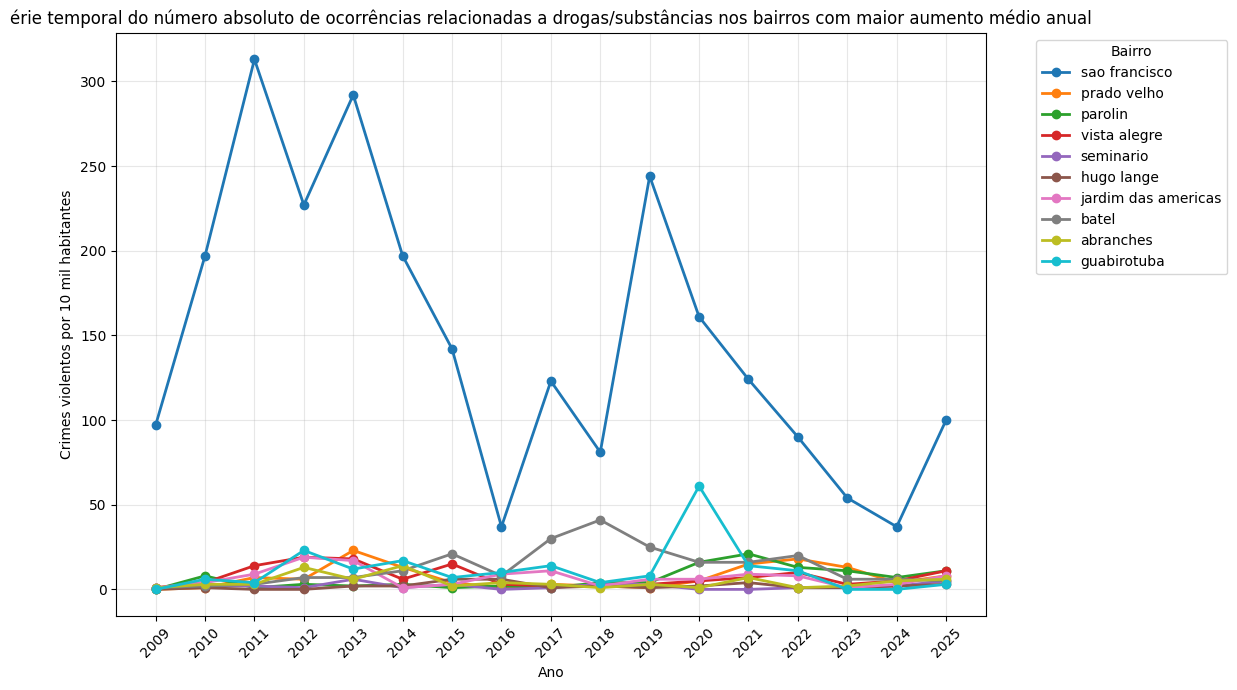

In [57]:
plt.figure(figsize=(12, 7))

for bairro in bairros_top10:
    dados_bairro = serie_top10[
        serie_top10["ATENDIMENTO_BAIRRO_NOME"] == bairro
    ]

    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro["total_crime_drogas_substancias"],
        marker="o",
        linewidth=2,
        label=bairro
    )

plt.xlabel("Ano")
plt.ylabel("Crimes violentos por 10 mil habitantes")
plt.title("érie temporal do número absoluto de ocorrências relacionadas a drogas/substâncias nos bairros com maior aumento médio anual")
plt.legend(title="Bairro", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.xticks(sorted(serie_top10["OCORRENCIA_ANO"].unique()), rotation=45)
plt.tight_layout()
plt.show()

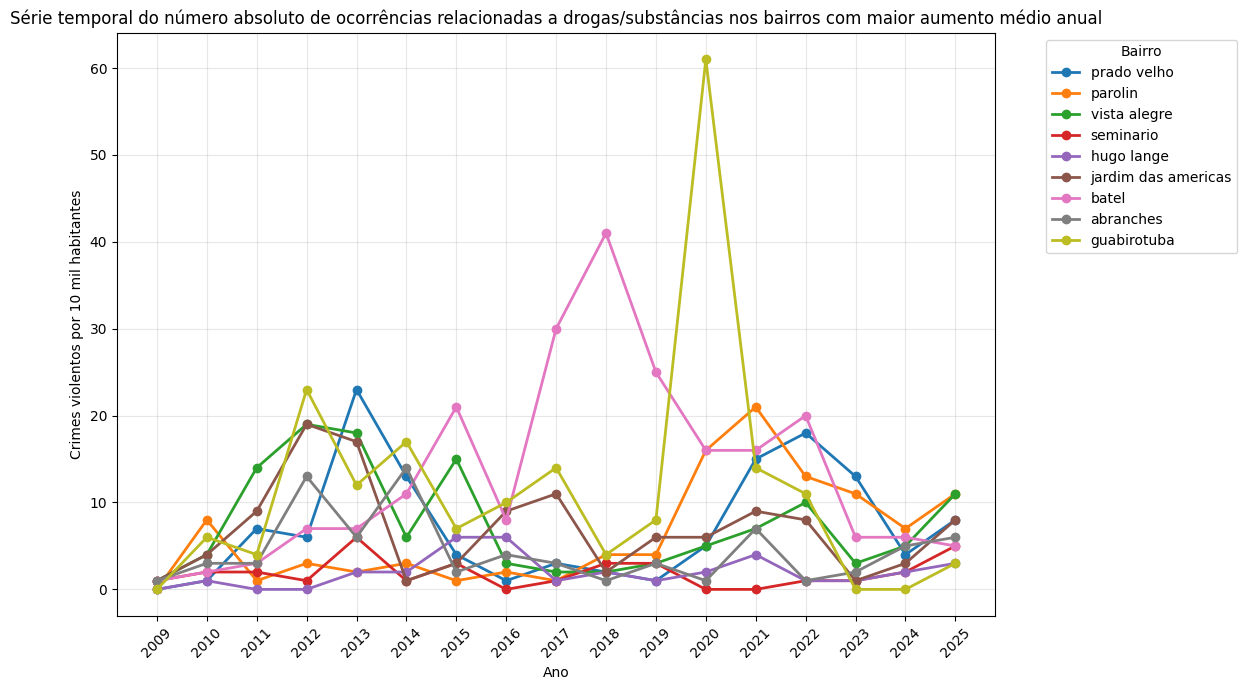

In [58]:
plt.figure(figsize=(12, 7))

for bairro in bairros_top10:
    if bairro == "sao francisco":
        continue 
    
    dados_bairro = serie_top10[
        serie_top10["ATENDIMENTO_BAIRRO_NOME"] == bairro
    ]

    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro["total_crime_drogas_substancias"],
        marker="o",
        linewidth=2,
        label=bairro
    )

plt.xlabel("Ano")
plt.ylabel("Crimes violentos por 10 mil habitantes")
plt.title("Série temporal do número absoluto de ocorrências relacionadas a drogas/substâncias nos bairros com maior aumento médio anual")
plt.legend(title="Bairro", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.xticks(sorted(serie_top10["OCORRENCIA_ANO"].unique()), rotation=45)
plt.tight_layout()
plt.show()


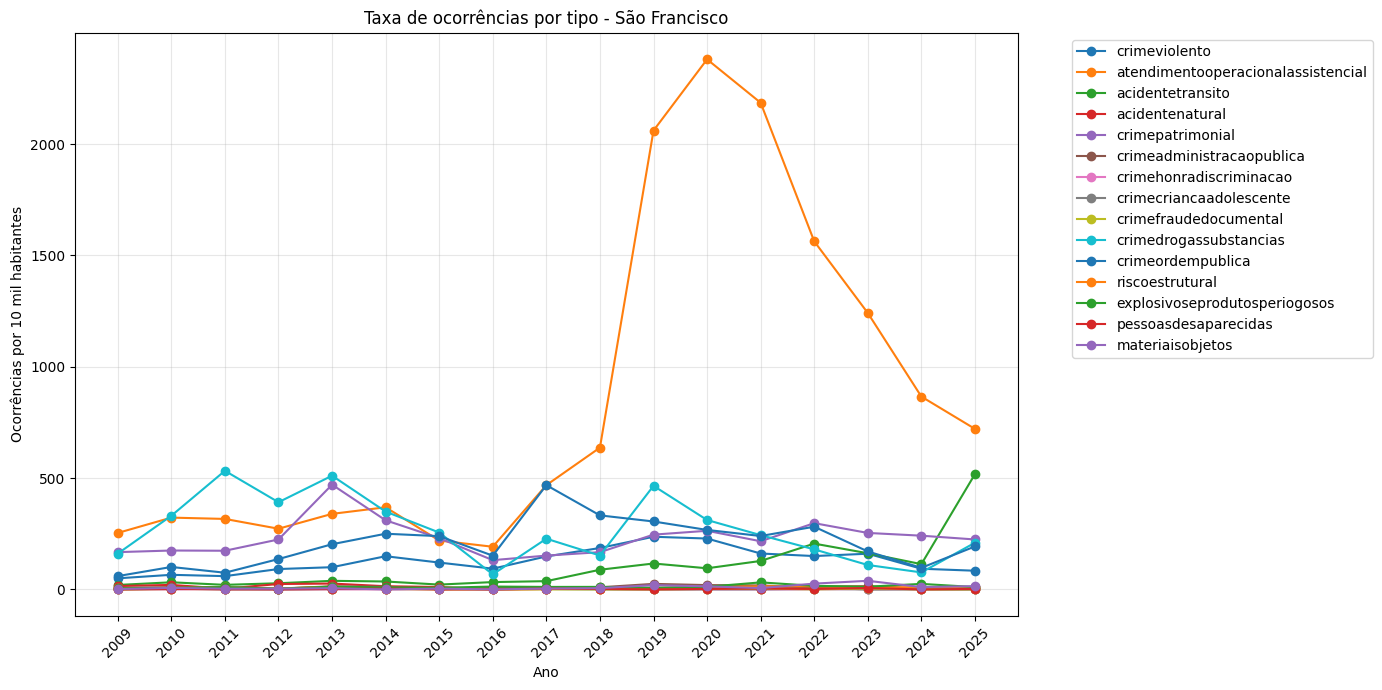

In [59]:
bairro = "sao francisco"

taxas_tipo_ocorrencia = [
    coluna for coluna in metricas_bairro_ano.columns
    if coluna.startswith("taxa_")
    and coluna.endswith("_10k")
    and coluna != "taxa_total_ocorrencias_10k"
]

dados_bairro = (
    metricas_bairro_ano[
        (metricas_bairro_ano["ATENDIMENTO_BAIRRO_NOME"] == bairro)
        & (metricas_bairro_ano["OCORRENCIA_ANO"] < 2026)
    ]
    .copy()
    .sort_values("OCORRENCIA_ANO")
)

plt.figure(figsize=(14, 7))

for coluna in taxas_tipo_ocorrencia:
    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro[coluna],
        marker="o",
        label=coluna.replace("taxa_", "").replace("_10k", "").replace("_", "")
    )

plt.title("Taxa de ocorrências por tipo - São Francisco")
plt.xlabel("Ano")
plt.ylabel("Ocorrências por 10 mil habitantes")
plt.xticks(dados_bairro["OCORRENCIA_ANO"], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

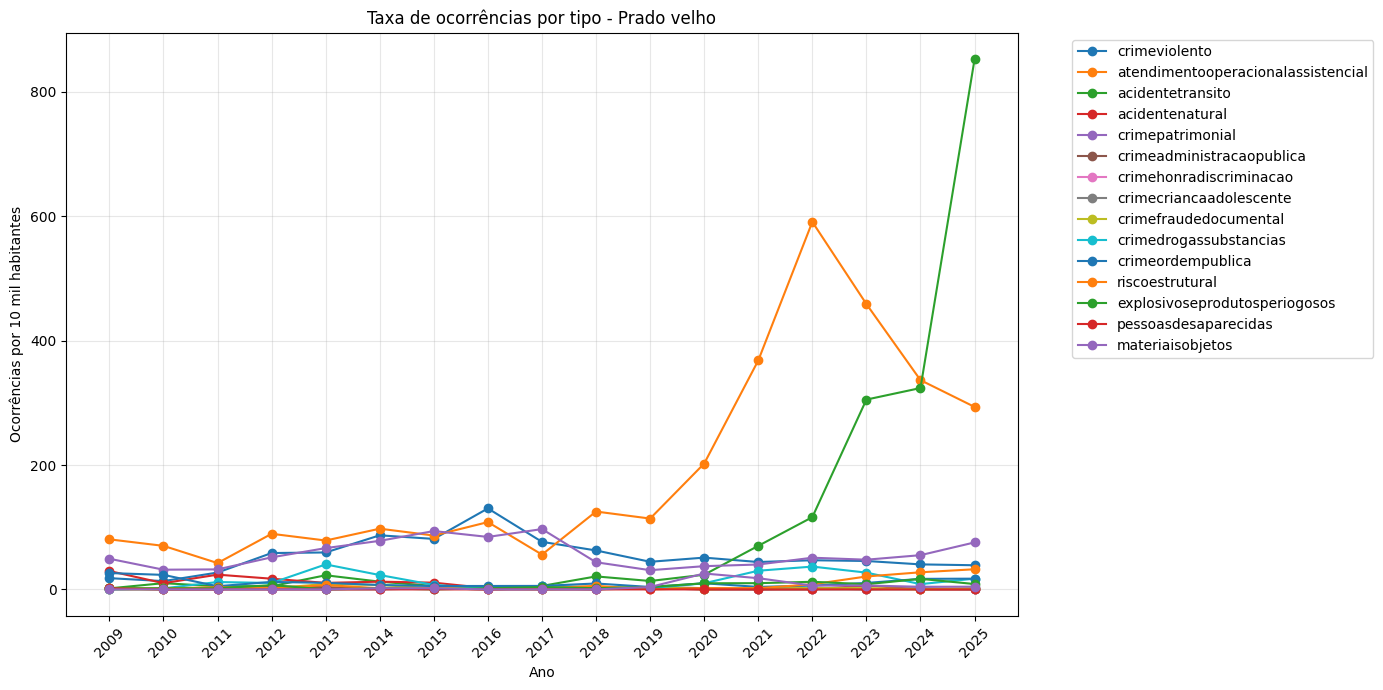

In [60]:
bairro = "prado velho"

taxas_tipo_ocorrencia = [
    coluna for coluna in metricas_bairro_ano.columns
    if coluna.startswith("taxa_")
    and coluna.endswith("_10k")
    and coluna != "taxa_total_ocorrencias_10k"
]

dados_bairro = (
    metricas_bairro_ano[
        (metricas_bairro_ano["ATENDIMENTO_BAIRRO_NOME"] == bairro)
        & (metricas_bairro_ano["OCORRENCIA_ANO"] < 2026)
    ]
    .copy()
    .sort_values("OCORRENCIA_ANO")
)

plt.figure(figsize=(14, 7))

for coluna in taxas_tipo_ocorrencia:
    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro[coluna],
        marker="o",
        label=coluna.replace("taxa_", "").replace("_10k", "").replace("_", "")
    )

plt.title("Taxa de ocorrências por tipo - Prado velho")
plt.xlabel("Ano")
plt.ylabel("Ocorrências por 10 mil habitantes")
plt.xticks(dados_bairro["OCORRENCIA_ANO"], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

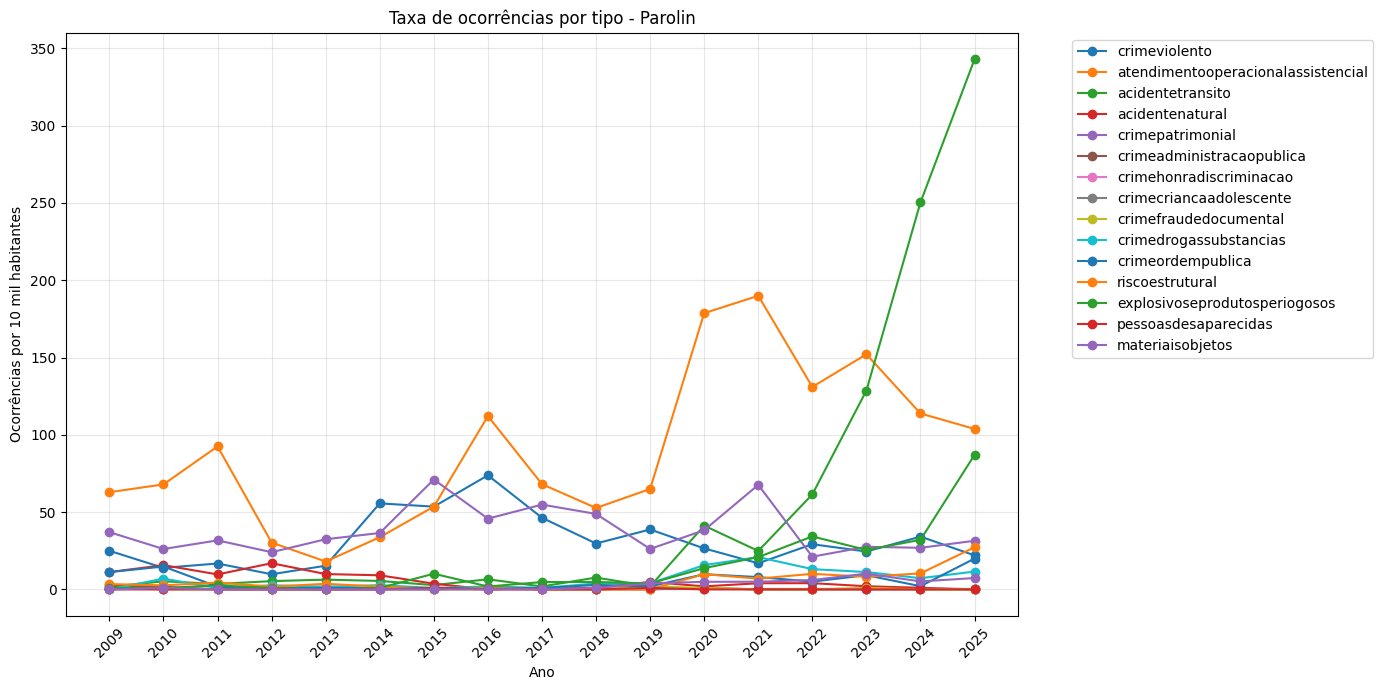

In [61]:
bairro = "parolin"

taxas_tipo_ocorrencia = [
    coluna for coluna in metricas_bairro_ano.columns
    if coluna.startswith("taxa_")
    and coluna.endswith("_10k")
    and coluna != "taxa_total_ocorrencias_10k"
]

dados_bairro = (
    metricas_bairro_ano[
        (metricas_bairro_ano["ATENDIMENTO_BAIRRO_NOME"] == bairro)
        & (metricas_bairro_ano["OCORRENCIA_ANO"] < 2026)
    ]
    .copy()
    .sort_values("OCORRENCIA_ANO")
)

plt.figure(figsize=(14, 7))

for coluna in taxas_tipo_ocorrencia:
    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro[coluna],
        marker="o",
        label=coluna.replace("taxa_", "").replace("_10k", "").replace("_", "")
    )

plt.title("Taxa de ocorrências por tipo - Parolin")
plt.xlabel("Ano")
plt.ylabel("Ocorrências por 10 mil habitantes")
plt.xticks(dados_bairro["OCORRENCIA_ANO"], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

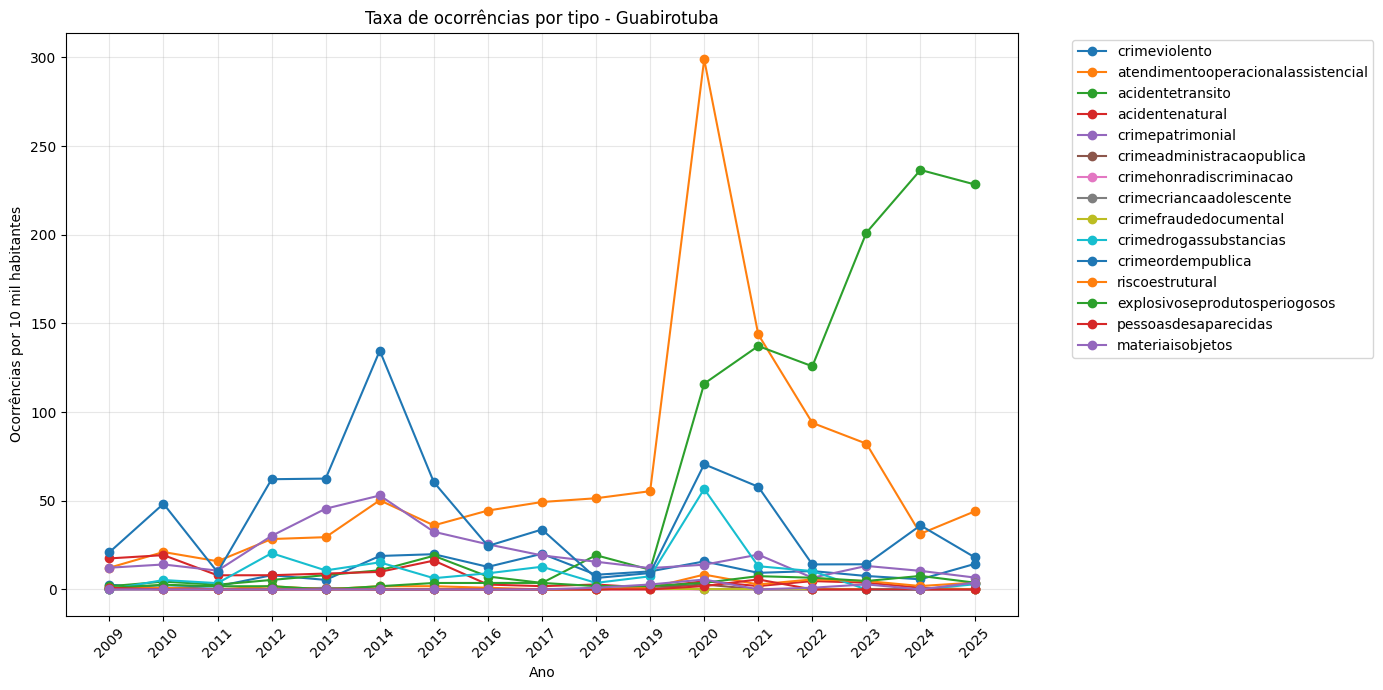

In [62]:
bairro = "guabirotuba"

taxas_tipo_ocorrencia = [
    coluna for coluna in metricas_bairro_ano.columns
    if coluna.startswith("taxa_")
    and coluna.endswith("_10k")
    and coluna != "taxa_total_ocorrencias_10k"
]

dados_bairro = (
    metricas_bairro_ano[
        (metricas_bairro_ano["ATENDIMENTO_BAIRRO_NOME"] == bairro)
        & (metricas_bairro_ano["OCORRENCIA_ANO"] < 2026)
    ]
    .copy()
    .sort_values("OCORRENCIA_ANO")
)

plt.figure(figsize=(14, 7))

for coluna in taxas_tipo_ocorrencia:
    plt.plot(
        dados_bairro["OCORRENCIA_ANO"],
        dados_bairro[coluna],
        marker="o",
        label=coluna.replace("taxa_", "").replace("_10k", "").replace("_", "")
    )

plt.title("Taxa de ocorrências por tipo - Guabirotuba")
plt.xlabel("Ano")
plt.ylabel("Ocorrências por 10 mil habitantes")
plt.xticks(dados_bairro["OCORRENCIA_ANO"], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 2. Métricas temporais



Para analisar a distribuição temporal das ocorrências registradas pela Guarda Municipal, os dados serão filtrados pelas colunas:

- `MADRUGADA`;
- `MANHA`;
- `TARDE`;
- `NOITE`.

Com isso, será calculado o total de ocorrências de cada tipo em cada período do dia.

In [63]:
periodos_dia = ["MADRUGADA", "MANHA", "TARDE", "NOITE"]

In [64]:
df_temporal = (
    df_metricas[
        df_metricas["OCORRENCIA_ANO"] < 2026
    ]
    .copy()
)

In [65]:
for coluna in periodos_dia + colunas_tipo_ocorrencia:
    df_temporal[coluna] = pd.to_numeric(
        df_temporal[coluna],
        errors="coerce"
    ).fillna(0).astype(int)

In [66]:
ocorrencias_por_periodo = []

for periodo in periodos_dia:
    for tipo_ocorrencia in colunas_tipo_ocorrencia:
        total = (
            df_temporal[periodo]
            * df_temporal[tipo_ocorrencia]
        ).sum()

        ocorrencias_por_periodo.append(
            {
                "periodo": periodo,
                "tipo_ocorrencia": tipo_ocorrencia,
                "total_ocorrencias": total,
            }
        )

In [67]:
ocorrencias_por_periodo = pd.DataFrame(ocorrencias_por_periodo)

In [68]:
ocorrencias_por_periodo["tipo_ocorrencia_formatado"] = (
    ocorrencias_por_periodo["tipo_ocorrencia"]
    .str.replace("_", " ")
    .str.title()
)

In [69]:
top_ocorrencias_por_periodo = (
    ocorrencias_por_periodo
    .sort_values(
        ["periodo", "total_ocorrencias"],
        ascending=[True, False]
    )
    .groupby("periodo")
    .head(5)
    .reset_index(drop=True)
)

In [70]:
top_ocorrencias_por_periodo

,periodo,tipo_ocorrencia,total_ocorrencias,tipo_ocorrencia_formatado
0,MADRUGADA,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,19195,Atendimento Operacional Assistencial
1,MADRUGADA,CRIME_PATRIMONIAL,13632,Crime Patrimonial
2,MADRUGADA,CRIME_ORDEM_PUBLICA,13364,Crime Ordem Publica
3,MADRUGADA,CRIME_VIOLENTO,6340,Crime Violento
4,MADRUGADA,ACIDENTE_TRANSITO,3339,Acidente Transito
5,MANHA,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,67244,Atendimento Operacional Assistencial
6,MANHA,ACIDENTE_TRANSITO,27781,Acidente Transito
7,MANHA,CRIME_PATRIMONIAL,13643,Crime Patrimonial
8,MANHA,CRIME_VIOLENTO,11134,Crime Violento
9,MANHA,ACIDENTE_NATURAL,7004,Acidente Natural


As ocorrências relacionadas a crimes não violentos são o tipo de ocorrência mais frequente em todos os períodos do dia, com maior concentração durante a tarde a manhã. 

Acidentes de trânsito aparecem com destaque principalmente na tarde, na noite e na manhã, o que pode estar associado aos horários de maior deslocamento da população.

Já os crimes patrimoniais e os crimes violentos aparecem entre os cinco tipos mais frequentes em todos os períodos, mas apresentam valores mais elevados no período da noite, especialmente os crimes violentos.

A madrugada apresenta os menores valores totais absolutos, mas ainda concentra ocorrência relevantes de crimes não violentos, patrimoniais, contra a ordem pública e violentos.

In [71]:
nomes_periodos = {
    "MADRUGADA": "Madrugada",
    "MANHA": "Manhã",
    "TARDE": "Tarde",
    "NOITE": "Noite",
}

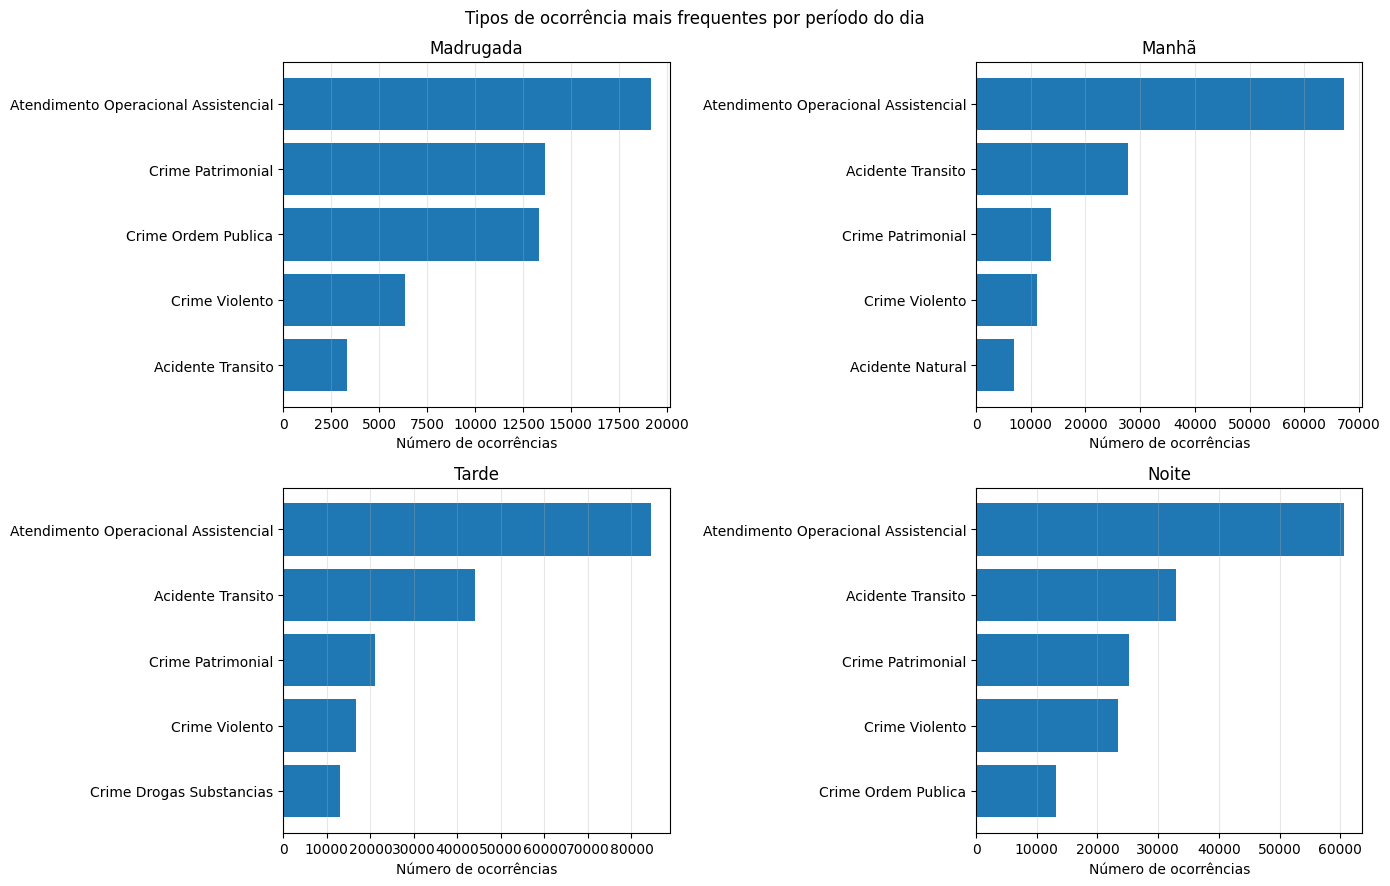

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, periodo in enumerate(periodos_dia):
    dados_plot = (
        top_ocorrencias_por_periodo[
            top_ocorrencias_por_periodo["periodo"] == periodo
        ]
        .sort_values("total_ocorrencias", ascending=True)
    )

    axes[i].barh(
        dados_plot["tipo_ocorrencia_formatado"],
        dados_plot["total_ocorrencias"]
    )

    axes[i].set_title(nomes_periodos[periodo])
    axes[i].set_xlabel("Número de ocorrências")
    axes[i].set_ylabel("")
    axes[i].grid(axis="x", alpha=0.3)

plt.suptitle("Tipos de ocorrência mais frequentes por período do dia")
plt.tight_layout()
plt.show()

In [73]:
tipos_plot = [
      "ATENDIMENTO_OPERACIONAL_ASSISTENCIAL",
      "CRIME_PATRIMONIAL",
      "CRIME_ORDEM_PUBLICA",
      "CRIME_VIOLENTO",
      "ACIDENTE_TRANSITO",
  ]

In [74]:
nomes_tipos = {
      "ATENDIMENTO_OPERACIONAL_ASSISTENCIAL": "Atendimento operacional/assistencial",
      "CRIME_PATRIMONIAL": "Crime patrimonial",
      "CRIME_ORDEM_PUBLICA": "Crime contra a ordem publica",
      "CRIME_VIOLENTO": "Crime violento",
      "ACIDENTE_TRANSITO": "Acidente de transito",
  }


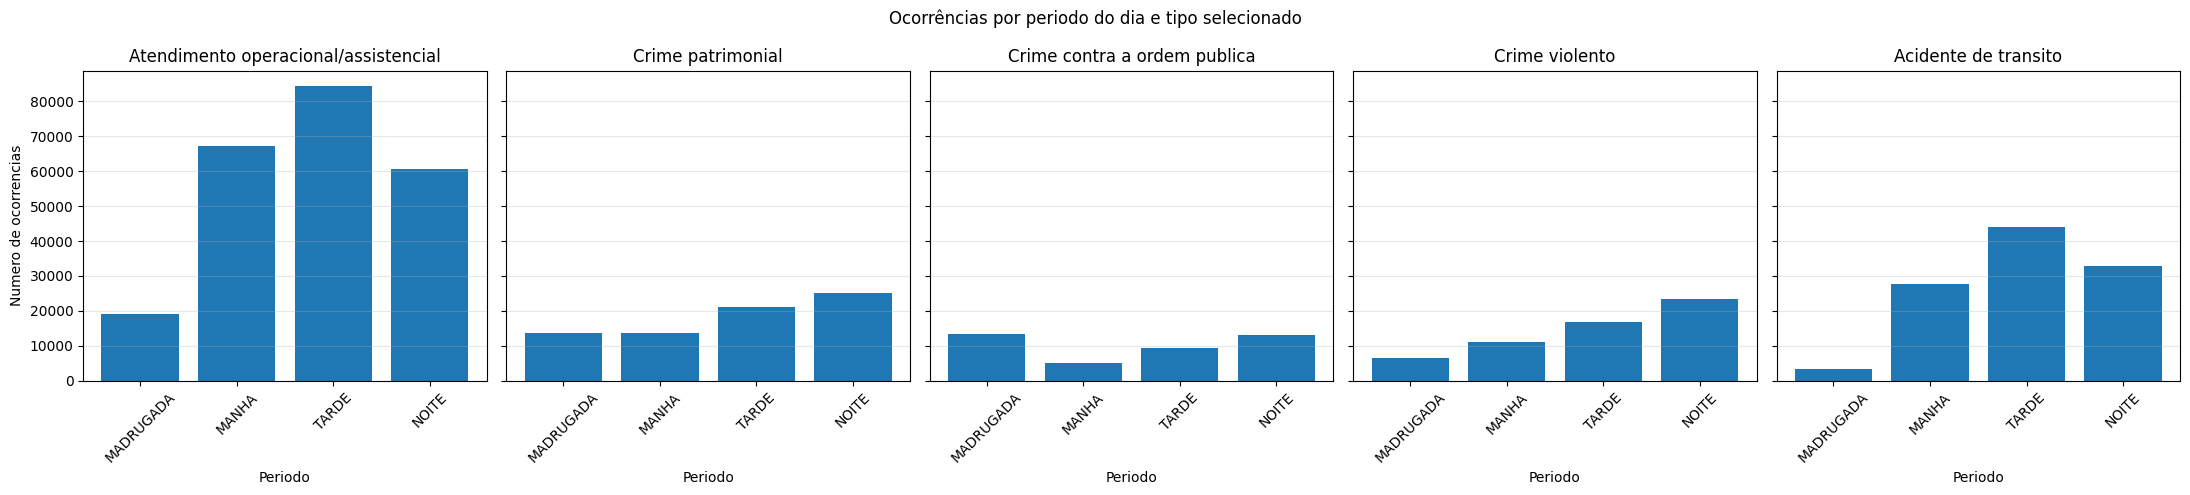

In [75]:
ordem_periodos = ["MADRUGADA", "MANHA", "TARDE", "NOITE"]

dados_plot = (
    ocorrencias_por_periodo[
        ocorrencias_por_periodo["tipo_ocorrencia"].isin(tipos_plot)
    ]
    .copy()
)

dados_plot["periodo"] = pd.Categorical(
    dados_plot["periodo"],
    categories=ordem_periodos,
    ordered=True
)

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, tipo in zip(axes, tipos_plot):
    dados_tipo = (
        dados_plot[dados_plot["tipo_ocorrencia"] == tipo]
        .sort_values("periodo")
    )

    ax.bar(
        dados_tipo["periodo"],
        dados_tipo["total_ocorrencias"]
    )

    ax.set_title(nomes_tipos[tipo])
    ax.set_xlabel("Periodo")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Numero de ocorrencias")

plt.suptitle("Ocorrências por periodo do dia e tipo selecionado")
plt.tight_layout()
plt.savefig(
    caminho_imagens / "metrica_temporal_ocorrencias_por_periodo_do_dia.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 3. Métricas socioeconômicas

As métricas socioecononômicas disponíveis no dataset são:

- `rendimento_medio_responsavel_sm_estimado`
- `pct_alfabetizacao_15mais_estimado`
- `pct_analfabetismo_15mais_estimado`
- `resp_domicilios_particulares_estimado`
- `pop_15mais_estimado`

### 3.1 Análise de renda por bairro

Para cada bairro, calcularemos a média histórica da renda ao longo dos anos. Para isso, obteremos a renda média anual de cada bairro e, posteriormente, calcularemos a média dessas rendas ao longo do período observado. Matematicamente, para um bairro $b$, a renda histórica média será calcula por:

$$
\bar{R}_{b} = \frac{1}{n_{b}}\sum_{i = 1}^{n_{b}}R_{b, i}
$$

onde:

- $\bar{R}_{b}$ é a renda histórica média do bairro $b$;
- $R_{b, i}$ é a renda média observado no bairro $b$ no ano $i$;
- $n_{b}$ é o número de anos observados para cada bairro $b$.

Com base nessa métrica, criaremos três grupos socioeconômicos:

1. os bairros com menor renda histórica média;
2. os bairros com maior renda histórica média;
3. os bairros com renda intermerdiária.

Os bairros com renda intermediária serão obtidas pelo grupo de 10 bairros cuja renda histórica média está mais próxima da mediana geral.

In [76]:
coluna_renda = "rendimento_medio_responsavel_sm_estimado"
n_bairros = 10

In [77]:
df_metricas[coluna_renda] = pd.to_numeric(
    df_metricas[coluna_renda].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

In [78]:
renda_historica_bairro = (
    df_metricas[df_metricas["OCORRENCIA_ANO"] < 2026]
    .groupby(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"], as_index=False)
    .agg(renda_media_ano_sm=(coluna_renda, "first"))
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        renda_historica_media_sm=("renda_media_ano_sm", "mean"),
        anos_renda_observados=("OCORRENCIA_ANO", "nunique")
    )
    .dropna(subset=["renda_historica_media_sm"])
)


In [79]:
idx_menor_renda = (
    renda_historica_bairro
    .nsmallest(n_bairros, "renda_historica_media_sm")
    .index
)

In [80]:
idx_maior_renda = (
    renda_historica_bairro
    .nlargest(n_bairros, "renda_historica_media_sm")
    .index
)

In [81]:
renda_mediana = renda_historica_bairro["renda_historica_media_sm"].median()

In [82]:
idx_renda_intermediaria = (
    renda_historica_bairro
    .drop(index=idx_menor_renda.union(idx_maior_renda))
    .assign(
        distancia_para_mediana=lambda df: (
            df["renda_historica_media_sm"] - renda_mediana
        ).abs()
    )
    .nsmallest(n_bairros, "distancia_para_mediana")
    .index
)

In [83]:
df_bairros_renda_historica = pd.concat(
    [
        renda_historica_bairro
        .loc[idx_menor_renda]
        .assign(grupo_renda="menor renda historica"),

        renda_historica_bairro
        .loc[idx_renda_intermediaria]
        .assign(grupo_renda="renda historica intermediaria"),

        renda_historica_bairro
        .loc[idx_maior_renda]
        .assign(grupo_renda="maior renda historica"),
    ],
    ignore_index=True
)

In [84]:
ordem_grupos_renda = [
    "menor renda historica",
    "renda historica intermediaria",
    "maior renda historica",
]

In [85]:
df_bairros_renda_historica["grupo_renda"] = pd.Categorical(
    df_bairros_renda_historica["grupo_renda"],
    categories=ordem_grupos_renda,
    ordered=True
)

In [86]:
df_bairros_renda_historica = (
    df_bairros_renda_historica
    .sort_values(["grupo_renda", "renda_historica_media_sm"])
    .round({"renda_historica_media_sm": 2})
    .reset_index(drop=True)
)

In [87]:
display(df_bairros_renda_historica)

,ATENDIMENTO_BAIRRO_NOME,renda_historica_media_sm,anos_renda_observados,grupo_renda
0,caximba,1.54,17,menor renda historica
1,sao miguel,1.86,17,menor renda historica
2,tatuquara,1.90,17,menor renda historica
3,ganchinho,1.97,17,menor renda historica
4,campo do santana,2.06,17,menor renda historica
5,sitio cercado,2.36,17,menor renda historica
6,augusta,2.43,17,menor renda historica
7,prado velho,2.46,17,menor renda historica
8,umbara,2.68,17,menor renda historica
9,cachoeira,2.70,17,menor renda historica


- O grupo de menor renda histórica apresenta valores entre 1.54 e 2.70 salários mínimos, sendo Caximba o bairro com menor renda média do período.

- O grupo intermediário concentra bairros com renda próxima à mediana, variando entre 4.15 e 4.80 salários mínimos.

- O grupo com maior renda histórica apresenta valores bem superiores, entre 9.06 e 13.77 salários mínimos, sendo o Batel a maior renda média histórica (13.77).

### Mapa cartográfico

Iremos utilizar a renda média histórica calculada para gerar um mapa cartográfico da cidade de Curitiba, utilizando como camada o mapa do GeoCuritiba/IPPUC, pois ela fornece os polígonos oficiais dos bairros de Curitiba, permitindo colsuta em formato GeoJSON, que é compatível com a biblioteca GeoPandas utilizada. Essa camada também possui o campo `nome`, que será utilizado para relacionar com a coluna `ATENDIMENTO_BAIRRO_NOME`.

Link: 

https://geocuritiba.ippuc.org.br/server/rest/services/GeoCuritiba/Publico_Interno_GeoCuritiba_BaseCartografica_para_BC/MapServer/44

https://ippuc.org.br/geodownloads/geo.htm

https://geopandas.org/en/stable/docs/reference/api/geopandas.read_file.html

https://geopandas.org/en/v0.9.0/docs/user_guide/mapping.html#choropleth-maps

Primeiro, vamos ajustar o nome do bairro Cidade Industrial para ser compatível com a nossa base de dados:

In [88]:
AJUSTES_BAIRROS = {
    "cidade industrial de curitiba": "cidade industrial",
}

Utilizaremos a função que normaliza o nome dos bairros para deixa-los compatíveis com `ATENDIMENTO_BAIRRO_NOME`

In [89]:
def normalizar_bairro(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome)
    nome = "".join(c for c in nome if not unicodedata.combining(c))
    nome = " ".join(nome.split())

    nome = AJUSTES_BAIRROS.get(nome, nome)
    nome = MAPA_BAIRRO.get(nome, nome)

    return nome

In [90]:
renda_mapa = renda_historica_bairro.copy()

renda_mapa["bairro_join"] = (
    renda_mapa["ATENDIMENTO_BAIRRO_NOME"]
    .apply(normalizar_bairro)
)

Agora, leremos a camada oficial de bairros do GeoCuritiba/IPPUC:

In [91]:
url_base = (
    "https://geocuritiba.ippuc.org.br/server/rest/services/"
    "GeoCuritiba/Publico_Interno_GeoCuritiba_BaseCartografica_para_BC/"
    "MapServer/44/query"
)

params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson",
    "outSR": 4326,
}

url_bairros = f"{url_base}?{urlencode(params)}"

gdf_bairros = gpd.read_file(url_bairros)

gdf_bairros["bairro_join"] = (
    gdf_bairros["nome"]
    .apply(normalizar_bairro)
)

In [92]:
colunas_renda = [
    "bairro_join",
    "ATENDIMENTO_BAIRRO_NOME",
    "renda_historica_media_sm",
]

gdf_renda = gdf_bairros.merge(
    renda_mapa[colunas_renda],
    on="bairro_join",
    how="left",
    validate="one_to_one"
)

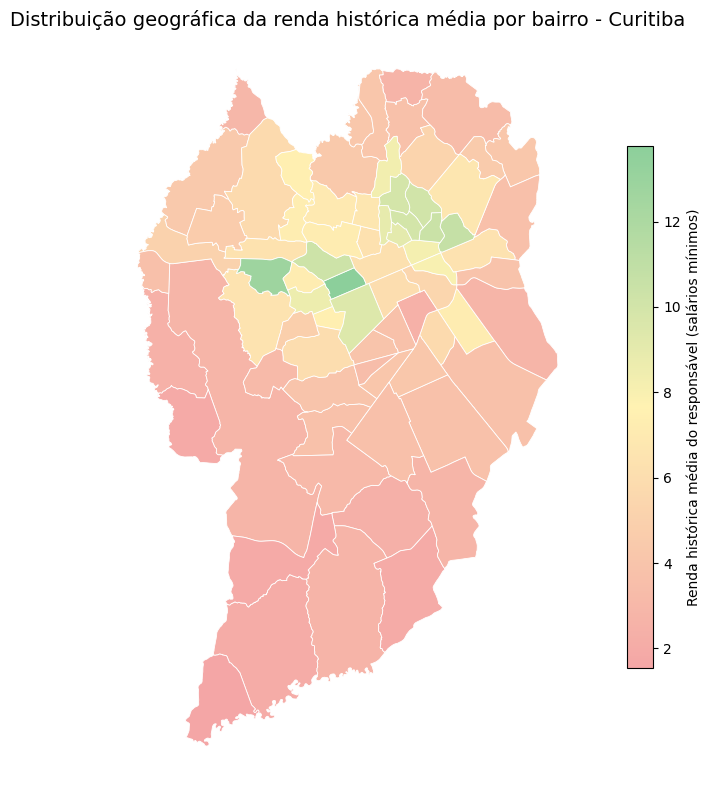

In [93]:
cmap_renda = LinearSegmentedColormap.from_list(
    "renda_vermelho_verde",
    ["#f4a6a6", "#fff2b2", "#8ccf9b"]
)

fig, ax = plt.subplots(figsize=(10, 8))

gdf_renda.plot(
    column="renda_historica_media_sm",
    ax=ax,
    cmap=cmap_renda,
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dado"
    },
    legend_kwds={
        "label": "Renda histórica média do responsável (salários mínimos)",
        "shrink": 0.7
    }
)

ax.set_title(
    "Distribuição geográfica da renda histórica média por bairro - Curitiba",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

## 3.2 Distribuição da renda história média por bairro

Nessa seção será analisada a distribuição da renda histórica média dos responsáveis pelos domicílios nos bairros de Curitiba.

In [94]:
coluna_renda = "rendimento_medio_responsavel_sm_estimado"

In [95]:
df_metricas[coluna_renda] = pd.to_numeric(
    df_metricas[coluna_renda].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

In [96]:
renda_historica_bairro = (
    df_metricas[df_metricas["OCORRENCIA_ANO"] < 2026]
    .groupby(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"], as_index=False)
    .agg(renda_media_ano_sm=(coluna_renda, "first"))
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        renda_historica_media_sm=("renda_media_ano_sm", "mean"),
        anos_observados=("OCORRENCIA_ANO", "nunique")
    )
    .dropna(subset=["renda_historica_media_sm"])
)

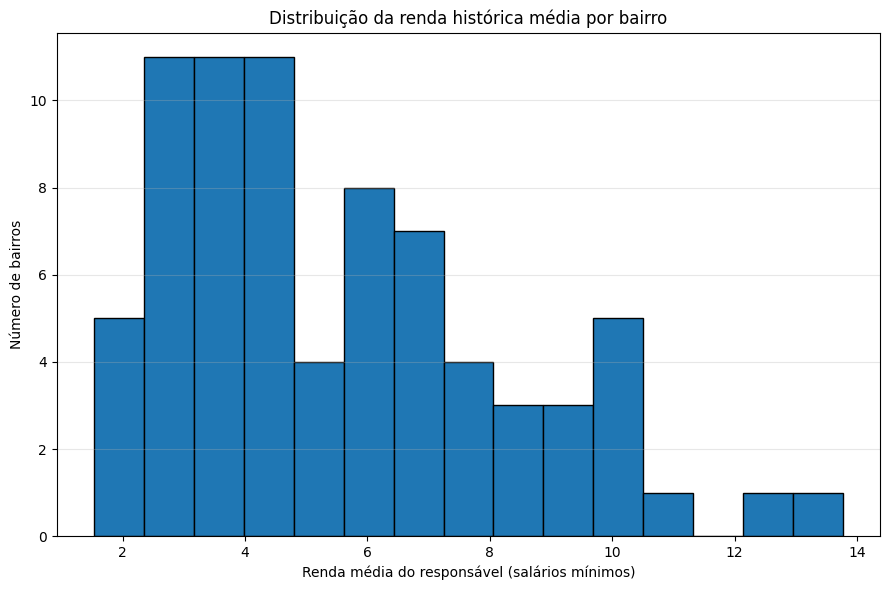

In [97]:
plt.figure(figsize=(9, 6))

plt.hist(
    renda_historica_bairro["renda_historica_media_sm"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribuição da renda histórica média por bairro")
plt.xlabel("Renda média do responsável (salários mínimos)")
plt.ylabel("Número de bairros")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [98]:
renda_historica_bairro["log_renda_historica_media_sm"] = np.log1p(
      renda_historica_bairro["renda_historica_media_sm"]
  )

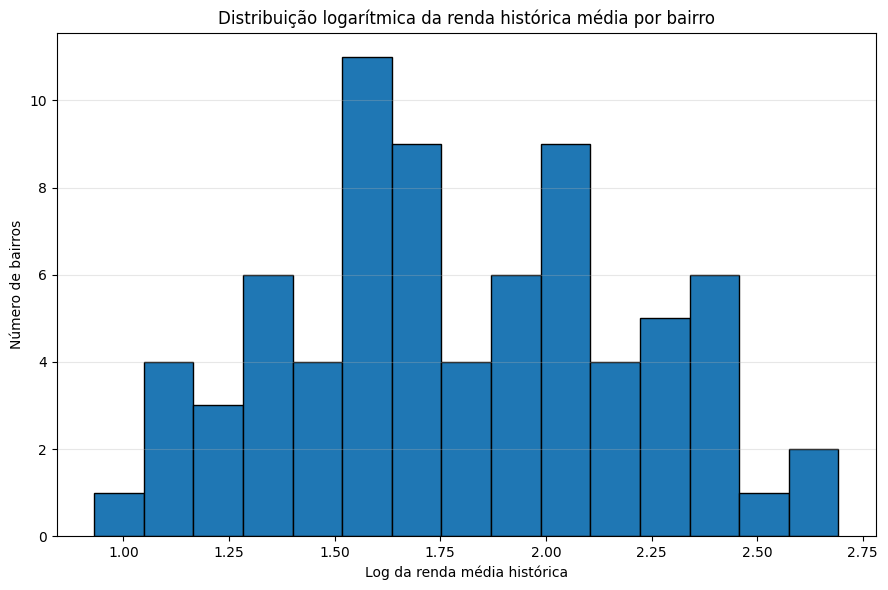

In [99]:
plt.figure(figsize=(9, 6))

plt.hist(
    renda_historica_bairro["log_renda_historica_media_sm"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribuição logarítmica da renda histórica média por bairro")
plt.xlabel("Log da renda média histórica")
plt.ylabel("Número de bairros")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Relação entre renda histórica média e ocorrências relacionas a drogas / substâncias

Agora, reutilizaremos as métricas de ocorrência já calculadas anteriormente em `metricas_bairro_ano`. A análise aqui apenas agrega essas métricas por grupos de renda histórica dos bairros.

Além disso, será calculada a proporção de ocorrências de drogas em relação ao total de ocorrências:

$$
P = \frac{O_{drogas}}{O_{total}} \times 100
$$

In [100]:
ocorrencias_drogas_bairros_renda = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .merge(
        df_bairros_renda_historica[
            [
                "ATENDIMENTO_BAIRRO_NOME",
                "grupo_renda",
                "renda_historica_media_sm"
            ]
        ],
        on="ATENDIMENTO_BAIRRO_NOME",
        how="inner"
    )
    .groupby(
        [
            "grupo_renda",
            "ATENDIMENTO_BAIRRO_NOME",
            "renda_historica_media_sm"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        total_ocorrencias=("total_ocorrencias", "sum"),
        total_drogas_substancias=("total_crime_drogas_substancias", "sum"),
        taxa_media_drogas_substancias_10k=(
            "taxa_crime_drogas_substancias_10k",
            "mean"
        ),
        anos_observados=("OCORRENCIA_ANO", "nunique")
    )
)

In [101]:
ocorrencias_drogas_bairros_renda["proporcao_drogas_substancias_pct"] = (
    ocorrencias_drogas_bairros_renda["total_drogas_substancias"]
    / ocorrencias_drogas_bairros_renda["total_ocorrencias"]
    * 100
)

In [102]:
ocorrencias_drogas_bairros_renda = (
    ocorrencias_drogas_bairros_renda
    .round(
        {
            "renda_historica_media_sm": 2,
            "taxa_media_drogas_substancias_10k": 2,
            "proporcao_drogas_substancias_pct": 2,
        }
    )
    .sort_values(
        [
            "grupo_renda",
            "taxa_media_drogas_substancias_10k"
        ],
        ascending=[True, False]
    )
)

In [103]:
ocorrencias_drogas_bairros_renda

,grupo_renda,ATENDIMENTO_BAIRRO_NOME,renda_historica_media_sm,total_ocorrencias,total_drogas_substancias,taxa_media_drogas_substancias_10k,anos_observados,proporcao_drogas_substancias_pct
5,menor renda historica,prado velho,2.46,4084,124,13.92,17,3.04
7,menor renda historica,sitio cercado,2.36,33140,1322,7.15,17,3.99
6,menor renda historica,sao miguel,1.86,1607,38,4.02,17,2.36
0,menor renda historica,augusta,2.43,2019,43,3.61,17,2.13
8,menor renda historica,tatuquara,1.90,14258,252,2.7,17,1.77
2,menor renda historica,campo do santana,2.06,6073,97,1.58,17,1.60
9,menor renda historica,umbara,2.68,3167,51,1.45,17,1.61
1,menor renda historica,cachoeira,2.70,1403,18,1.04,17,1.28
4,menor renda historica,ganchinho,1.97,2555,26,0.9,17,1.02
3,menor renda historica,caximba,1.54,811,3,0.25,17,0.37


Como visto anteriormente, as ocorrências relacionadas a drogas e substâncias aparecem em todos os grupos de renda, com forte variação entre bairros.

Entre os bairros de menor renda histórica, Prado Velho e Sítio Cercado contém as amiores taxas médias por 10 mil habitantes; no grupo intermediário, Taboão apresenta a maior taxa; e, entre os bairros de maior renda histórica, Batel e Bigorrilho se destacam tanto pela taxa quanto pela proporção de ocorrências de drogas no total do registro. Assim, os dados sugerem que esse tipo de ocorrência não se concentra apenas nos bairros de menor renda, aparecendo também com relevância em bairros de renda mais elevada.

In [104]:
metricas_drogas_plot = [
      ("taxa_media_drogas_substancias_10k", "Taxa media por 10 mil hab."),
      ("proporcao_drogas_substancias_pct", "% das ocorrencias"),
      ("total_drogas_substancias", "Total de ocorrencias"),
  ]


In [105]:
dados_plot = ocorrencias_drogas_bairros_renda.copy()

dados_plot["grupo_renda"] = pd.Categorical(
    dados_plot["grupo_renda"],
    categories=ordem_grupos_renda,
    ordered=True
  ) 

dados_plot = (
    dados_plot
    .sort_values(["grupo_renda", "renda_historica_media_sm"])
    .reset_index(drop=True)
    ) 

cores_grupo = {
    "menor renda historica": "#d95f02",
    "renda historica intermediaria": "#7570b3",
    "maior renda historica": "#1b9e77",
    } 

cores = dados_plot["grupo_renda"].astype(str).map(cores_grupo)

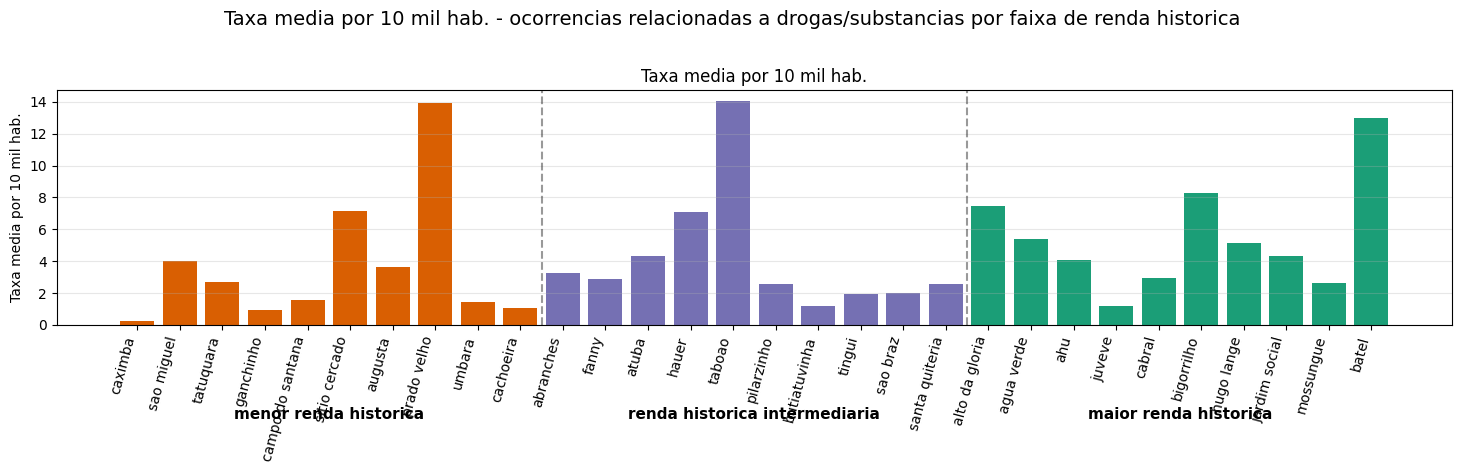

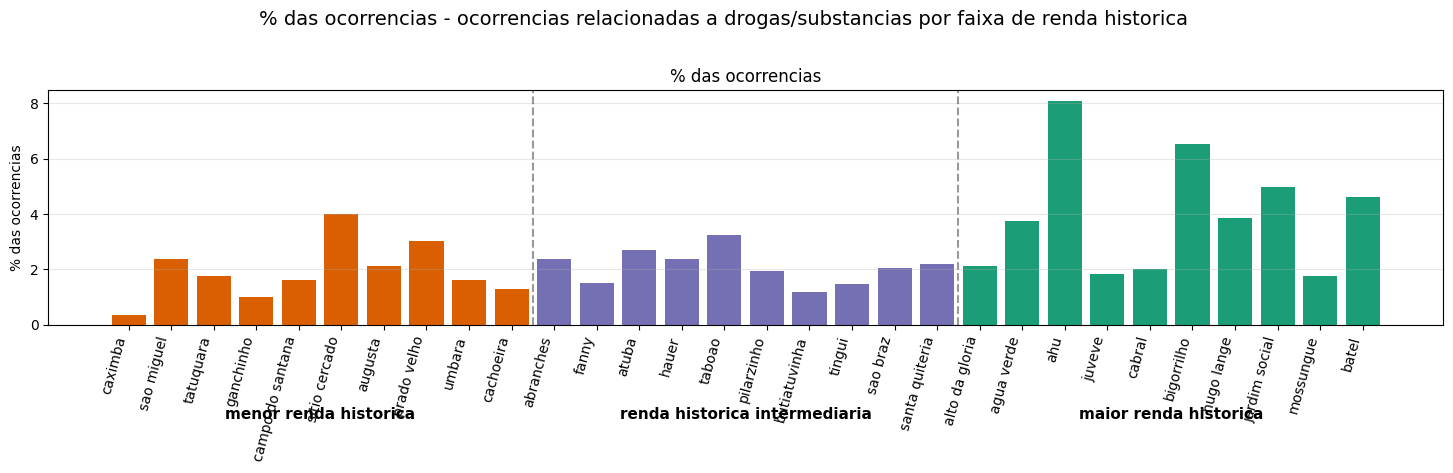

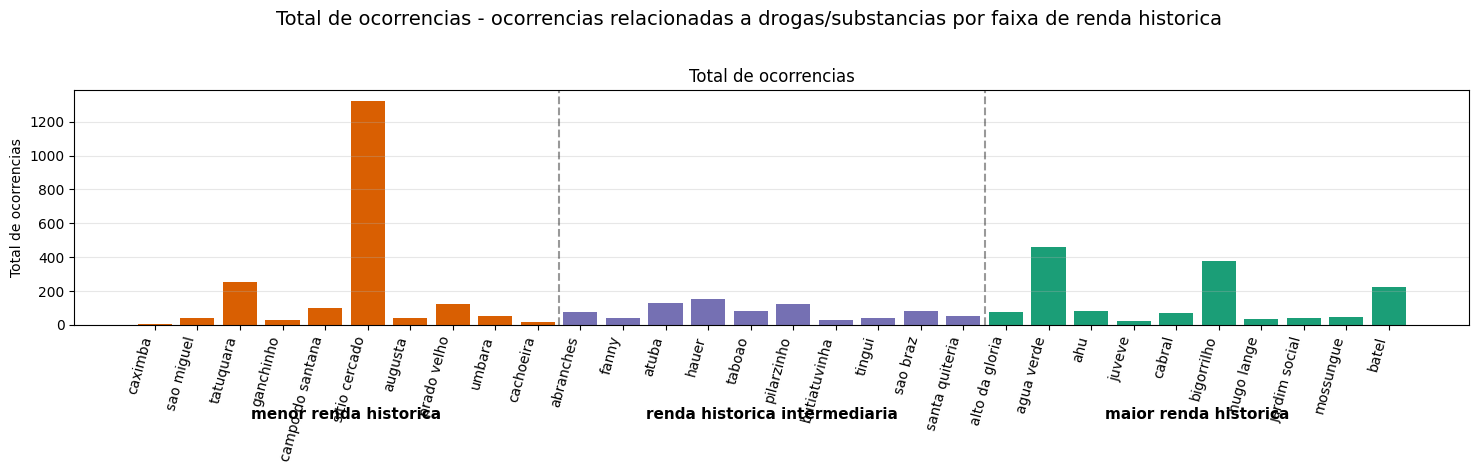

In [106]:
for metrica, titulo_eixo in metricas_drogas_plot:
    fig, ax = plt.subplots(figsize=(18, 5))

    ax.bar(
        range(len(dados_plot)),
        dados_plot[metrica],
        color=cores
    )

    ax.set_title(titulo_eixo)
    ax.set_ylabel(titulo_eixo)
    ax.grid(axis="y", alpha=0.3)

    for limite in [9.5, 19.5]:
        ax.axvline(limite, color="black", linestyle="--", alpha=0.4)

    ax.set_xticks(range(len(dados_plot)))
    ax.set_xticklabels(
        dados_plot["ATENDIMENTO_BAIRRO_NOME"],
        rotation=75,
        ha="right"
    )

    for posicao, grupo in zip([4.5, 14.5, 24.5], ordem_grupos_renda):
        ax.text(
            posicao,
            -0.35,
            grupo,
            ha="center",
            va="top",
            transform=ax.get_xaxis_transform(),
            fontsize=11,
            fontweight="bold"
        )

    fig.suptitle(
        f"{titulo_eixo} - ocorrencias relacionadas a drogas/substancias por faixa de renda historica",
          fontsize=14
      )

    fig.subplots_adjust(bottom=0.35, top=0.82)
    plt.show()


### Mapa geográfico

In [107]:
drogas_mapa = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        total_ocorrencias=("total_ocorrencias", "sum"),
        total_drogas_substancias=("total_crime_drogas_substancias", "sum"),
        taxa_media_drogas_substancias_10k=(
            "taxa_crime_drogas_substancias_10k",
            "mean"
        ),
        anos_observados=("OCORRENCIA_ANO", "nunique")
    )
)

In [108]:
drogas_mapa["proporcao_drogas_substancias_pct"] = (
    drogas_mapa["total_drogas_substancias"]
    / drogas_mapa["total_ocorrencias"]
    * 100
)

drogas_mapa["bairro_join"] = (
    drogas_mapa["ATENDIMENTO_BAIRRO_NOME"]
    .apply(normalizar_bairro)
)

In [109]:
drogas_mapa = drogas_mapa.round(
      {
        "taxa_media_drogas_substancias_10k": 2,
        "proporcao_drogas_substancias_pct": 2,
    }
)

In [110]:
colunas_drogas = [
    "bairro_join",
    "ATENDIMENTO_BAIRRO_NOME",
    "total_drogas_substancias",
    "taxa_media_drogas_substancias_10k",
    "proporcao_drogas_substancias_pct",
]

gdf_drogas = gdf_bairros.merge(
    drogas_mapa[colunas_drogas],
    on="bairro_join",
    how="left",
    validate="one_to_one"
)

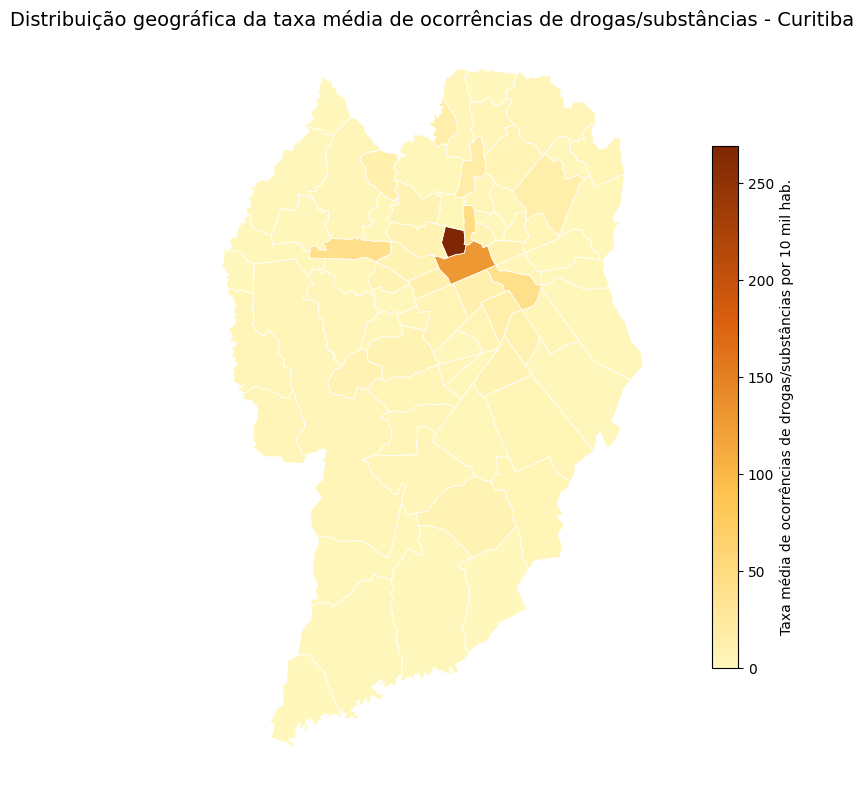

In [111]:
cmap_drogas = LinearSegmentedColormap.from_list(
    "drogas_amarelo_vermelho",
    ["#fff7bc", "#fec44f", "#d95f0e", "#7f2704"]
)

fig, ax = plt.subplots(figsize=(10, 8))

gdf_drogas.plot(
    column="taxa_media_drogas_substancias_10k",
    ax=ax,
    cmap=cmap_drogas,
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dado"
    },
    legend_kwds={
        "label": "Taxa média de ocorrências de drogas/substâncias por 10 mil hab.",
        "shrink": 0.7
    }
)

ax.set_title(
    "Distribuição geográfica da taxa média de ocorrências de drogas/substâncias - Curitiba",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

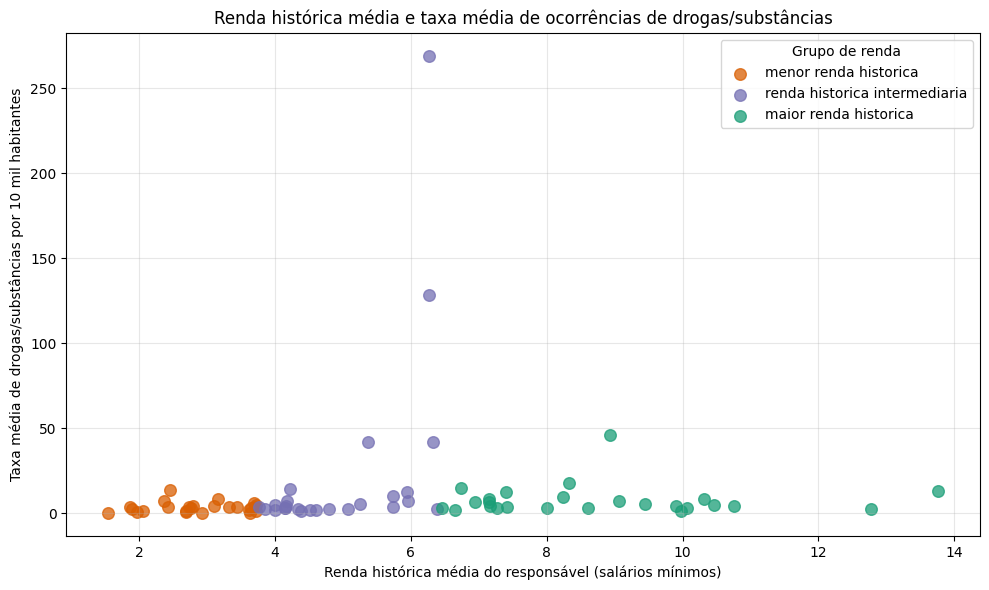

In [112]:
drogas_renda_todos_bairros = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        taxa_media_drogas_substancias_10k=(
            "taxa_crime_drogas_substancias_10k",
            "mean"
        )
    )
    .merge(
        renda_historica_bairro[
            [
                "ATENDIMENTO_BAIRRO_NOME",
                "renda_historica_media_sm"
            ]
        ],
        on="ATENDIMENTO_BAIRRO_NOME",
        how="inner"
    )
    .dropna()
)

q1 = drogas_renda_todos_bairros["renda_historica_media_sm"].quantile(1/3)
q2 = drogas_renda_todos_bairros["renda_historica_media_sm"].quantile(2/3)

drogas_renda_todos_bairros["grupo_renda"] = pd.cut(
    drogas_renda_todos_bairros["renda_historica_media_sm"],
    bins=[
        -float("inf"),
        q1,
        q2,
        float("inf")
    ],
    labels=[
        "menor renda historica",
        "renda historica intermediaria",
        "maior renda historica"
    ]
)

cores_grupo = {
    "menor renda historica": "#d95f02",
    "renda historica intermediaria": "#7570b3",
    "maior renda historica": "#1b9e77",
}

plt.figure(figsize=(10, 6))

for grupo, dados_grupo in drogas_renda_todos_bairros.groupby(
    "grupo_renda",
    observed=True
):
    plt.scatter(
        dados_grupo["renda_historica_media_sm"],
        dados_grupo["taxa_media_drogas_substancias_10k"],
        label=grupo,
        color=cores_grupo[str(grupo)],
        alpha=0.75,
        s=70
    )

plt.title("Renda histórica média e taxa média de ocorrências de drogas/substâncias")
plt.xlabel("Renda histórica média do responsável (salários mínimos)")
plt.ylabel("Taxa média de drogas/substâncias por 10 mil habitantes")
plt.legend(title="Grupo de renda")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [113]:
drogas_renda_todos_bairros_filtrado = (
    drogas_renda_todos_bairros[
        drogas_renda_todos_bairros["taxa_media_drogas_substancias_10k"] <= 40
    ]
    .copy()
)

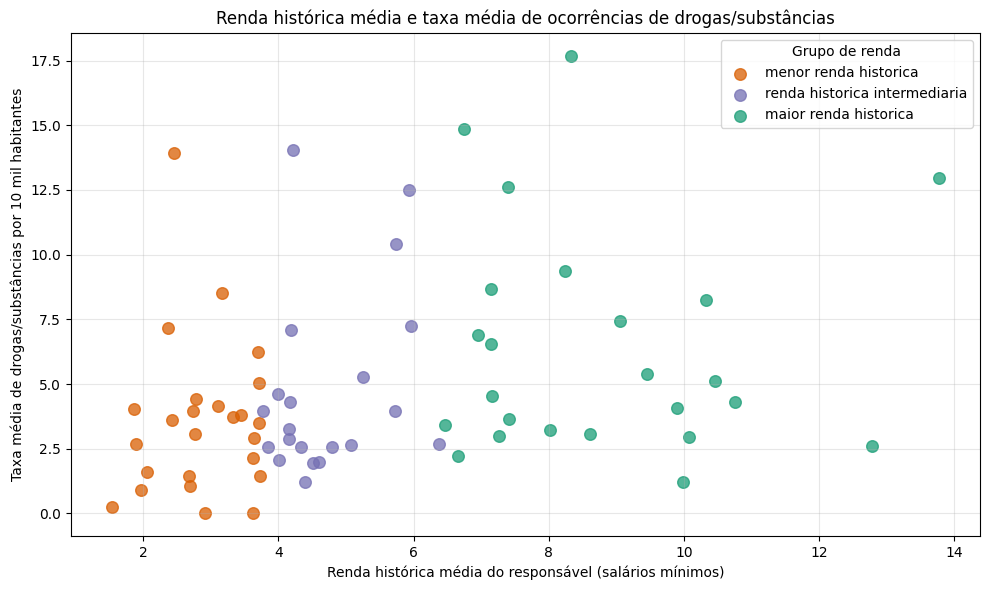

In [114]:
plt.figure(figsize=(10, 6))

for grupo, dados_grupo in drogas_renda_todos_bairros_filtrado.groupby(
    "grupo_renda",
    observed=True):
    plt.scatter(
        dados_grupo["renda_historica_media_sm"],
        dados_grupo["taxa_media_drogas_substancias_10k"],
        label=grupo,
        color=cores_grupo[str(grupo)],
        alpha=0.75,
        s=70
    )

plt.title("Renda histórica média e taxa média de ocorrências de drogas/substâncias")
plt.xlabel("Renda histórica média do responsável (salários mínimos)")
plt.ylabel("Taxa média de drogas/substâncias por 10 mil habitantes")
plt.legend(title="Grupo de renda")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    caminho_imagens / "renda_historica_media_e_taxa_media_de_ocorrencias_relacionadas_a_drogas.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3.3 Relação entre renda histórica média e ocorrências relacionadas à violência

Agora, reutilizaremos as métricas de ocorrência já calculadas anteriormente em `metricas_bairro_ano`. A análise aqui apenas agrega essas métricas por grupos de renda histórica dos bairros.

Além disso, será calculada a proporção de ocorrências de relacionadas a violência em relação ao total de ocorrências:

$$
P = \frac{O_{violencia}}{O_{total}} \times 100
$$

In [115]:
ocorrencias_violencia_bairros_renda = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .merge(
        df_bairros_renda_historica[
            [
                "ATENDIMENTO_BAIRRO_NOME",
                "grupo_renda",
                "renda_historica_media_sm"
            ]
        ],
        on="ATENDIMENTO_BAIRRO_NOME",
        how="inner"
    )
    .groupby(
        [
            "grupo_renda",
            "ATENDIMENTO_BAIRRO_NOME",
            "renda_historica_media_sm"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        total_ocorrencias=("total_ocorrencias", "sum"),
        total_violencia=("total_crime_violento", "sum"),
        taxa_media_violencia_10k=(
            "taxa_crime_violento_10k",
            "mean"
        ),
        anos_observados=("OCORRENCIA_ANO", "nunique")
    )
)

In [116]:
ocorrencias_violencia_bairros_renda["proporcao_violencia_pct"] = (
    ocorrencias_violencia_bairros_renda["total_violencia"]
    / ocorrencias_violencia_bairros_renda["total_ocorrencias"]
    * 100
)

In [117]:
ocorrencias_violencia_bairros_renda = (
    ocorrencias_violencia_bairros_renda
    .round(
        {
            "renda_historica_media_sm": 2,
            "taxa_media_violencia_10k": 2,
            "proporcao_violencia_pct": 2,
        }
    )
    .sort_values(
        [
            "grupo_renda",
            "taxa_media_violencia_10k"
        ],
        ascending=[True, False]
    )
)

In [118]:
ocorrencias_violencia_bairros_renda

,grupo_renda,ATENDIMENTO_BAIRRO_NOME,renda_historica_media_sm,total_ocorrencias,total_violencia,taxa_media_violencia_10k,anos_observados,proporcao_violencia_pct
5,menor renda historica,prado velho,2.46,4084,495,54.41,17,12.12
7,menor renda historica,sitio cercado,2.36,33140,3978,21.86,17,12.00
6,menor renda historica,sao miguel,1.86,1607,146,13.56,17,9.09
0,menor renda historica,augusta,2.43,2019,156,12.93,17,7.73
8,menor renda historica,tatuquara,1.90,14258,1193,12.68,17,8.37
2,menor renda historica,campo do santana,2.06,6073,599,9.26,17,9.86
4,menor renda historica,ganchinho,1.97,2555,270,9.16,17,10.57
1,menor renda historica,cachoeira,2.70,1403,131,7.03,17,9.34
9,menor renda historica,umbara,2.68,3167,250,6.95,17,7.89
3,menor renda historica,caximba,1.54,811,59,6.19,17,7.27


Os reusltados mostram que a violência não aumenta de forma linear conforme a renda diminui. Entre os bairros de menor renda histórica, o Prado Velho se destaca com a maior taxa de violência, 54.41 ocorrências por 10 mil habitantes, seguido pelo Sítio Cercado, que tem o maior volume de casos absolutos, com 3.978 ocorrências violentas. Porém, bairros de renda intermediária e alta também aparecem com taxas elevadas, como Taboão, Hauer, Alto da Glória, Cabral e Batel.

In [119]:
metricas_violencia_plot = [
    ("taxa_media_violencia_10k", "Taxa media por 10 mil hab."),
    ("proporcao_violencia_pct", "% das ocorrencias"),
    ("total_violencia", "Total de ocorrencias"),
]

In [120]:
dados_plot = ocorrencias_violencia_bairros_renda.copy()

dados_plot["grupo_renda"] = pd.Categorical(
    dados_plot["grupo_renda"],
    categories=ordem_grupos_renda,
    ordered=True
)

dados_plot = (
    dados_plot
    .sort_values(["grupo_renda", "renda_historica_media_sm"])
    .reset_index(drop=True)
)

In [121]:
cores_grupo = {
    "menor renda historica": "#d95f02",
    "renda historica intermediaria": "#7570b3",
    "maior renda historica": "#1b9e77",
}

cores = dados_plot["grupo_renda"].astype(str).map(cores_grupo)

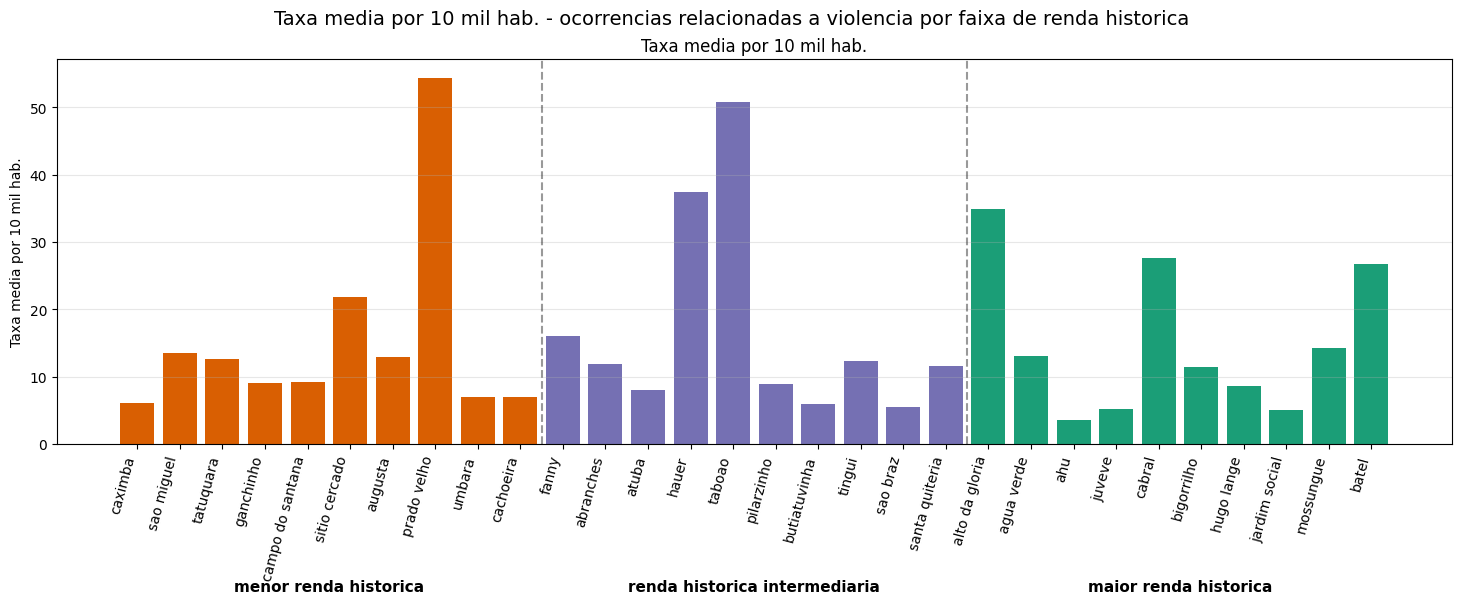

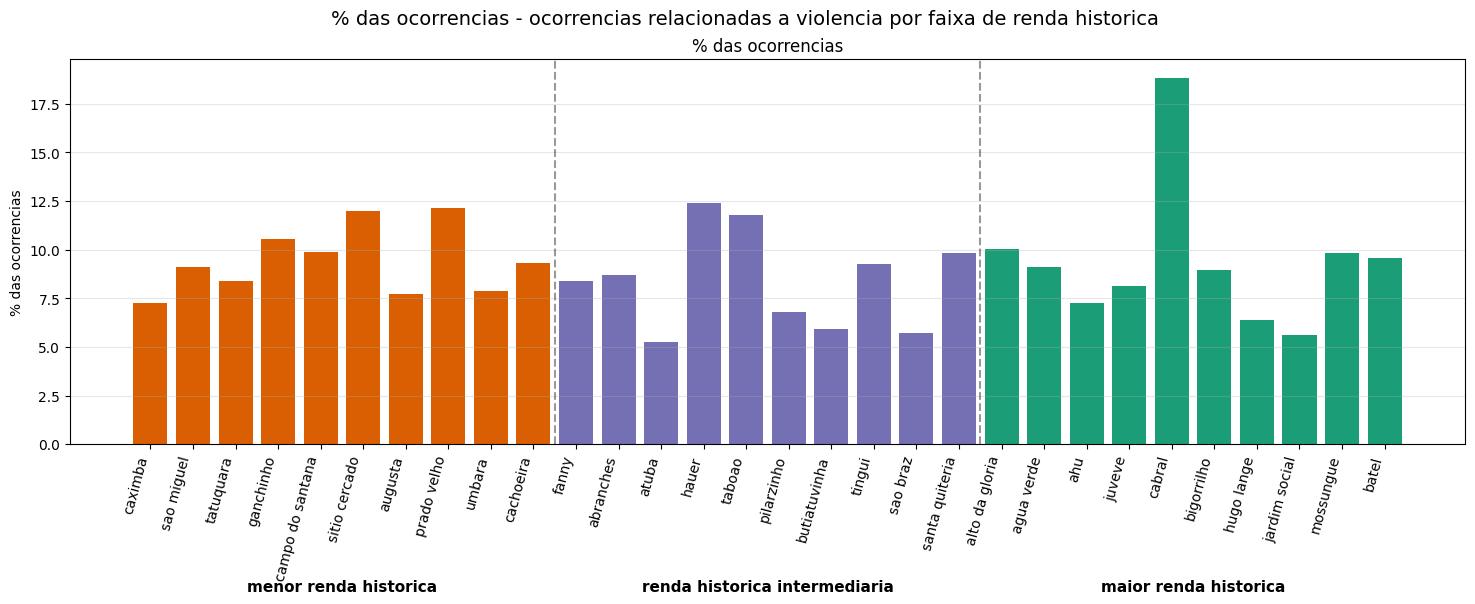

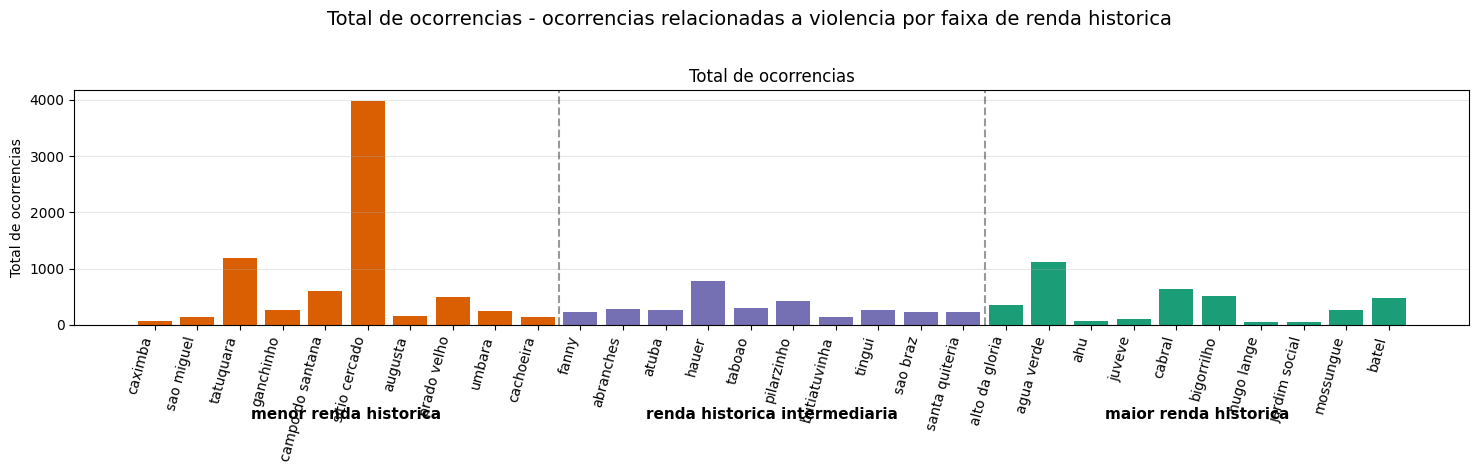

In [122]:
for metrica, titulo_eixo in metricas_violencia_plot:
    fig, ax = plt.subplots(figsize=(18, 5))

    ax.bar(
        range(len(dados_plot)),
        dados_plot[metrica],
        color=cores
    )

    ax.set_title(titulo_eixo)
    ax.set_ylabel(titulo_eixo)
    ax.grid(axis="y", alpha=0.3)

    for limite in [9.5, 19.5]:
        ax.axvline(limite, color="black", linestyle="--", alpha=0.4)

    ax.set_xticks(range(len(dados_plot)))
    ax.set_xticklabels(
        dados_plot["ATENDIMENTO_BAIRRO_NOME"],
        rotation=75,
        ha="right"
    )

    for posicao, grupo in zip([4.5, 14.5, 24.5], ordem_grupos_renda):
        ax.text(
            posicao,
            -0.35,
            grupo,
            ha="center",
            va="top",
            transform=ax.get_xaxis_transform(),
            fontsize=11,
            fontweight="bold"
        )

    fig.suptitle(f"{titulo_eixo} - ocorrencias relacionadas a violencia por faixa de renda historica",
        fontsize=14
    )

fig.subplots_adjust(bottom=0.35, top=0.82)
plt.show()

In [123]:
violencia_renda_todos_bairros = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        taxa_media_violencia_10k=("taxa_crime_violento_10k", "mean")
    )
    .merge(
        renda_historica_bairro[
            [
                "ATENDIMENTO_BAIRRO_NOME",
                "renda_historica_media_sm"
            ]
        ],
        on="ATENDIMENTO_BAIRRO_NOME",
        how="inner"
    )
    .dropna()
)

In [124]:
q1 = violencia_renda_todos_bairros["renda_historica_media_sm"].quantile(1/3)
q2 = violencia_renda_todos_bairros["renda_historica_media_sm"].quantile(2/3)

violencia_renda_todos_bairros["grupo_renda"] = pd.cut(
    violencia_renda_todos_bairros["renda_historica_media_sm"],
    bins=[
        -float("inf"),
        q1,
        q2,
        float("inf")
    ],
    labels=[
        "menor renda historica",
        "renda historica intermediaria",
        "maior renda historica"
    ]
)

In [125]:
cores_grupo = {
      "menor renda historica": "#d95f02",
      "renda historica intermediaria": "#7570b3",
      "maior renda historica": "#1b9e77",
  }


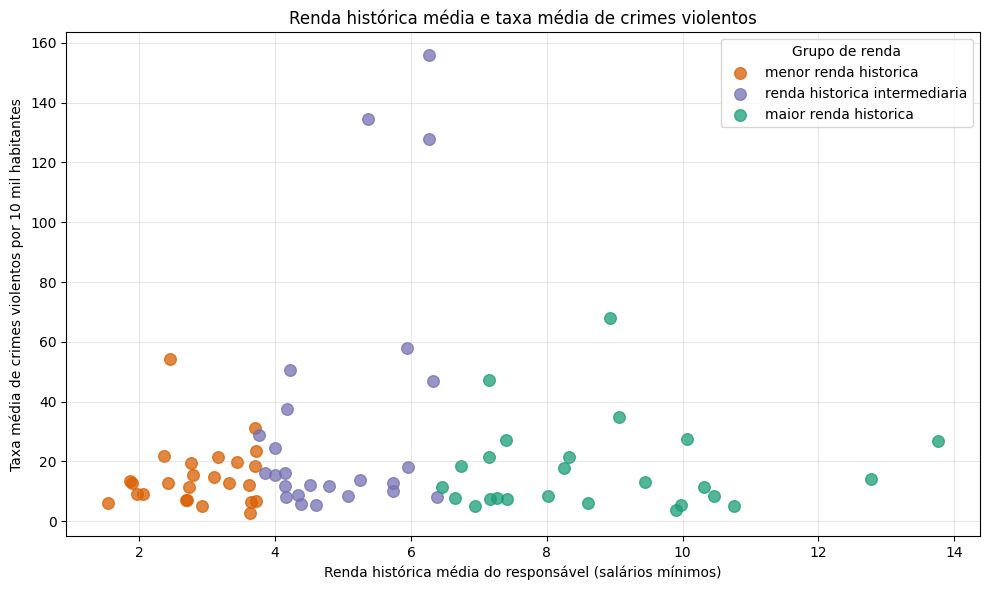

In [126]:
plt.figure(figsize=(10, 6))

for grupo, dados_grupo in violencia_renda_todos_bairros.groupby("grupo_renda", observed=True):
    plt.scatter(
        dados_grupo["renda_historica_media_sm"],
        dados_grupo["taxa_media_violencia_10k"],
        label=grupo,
        color=cores_grupo[str(grupo)],
        alpha=0.75,
        s=70
    )

plt.title("Renda histórica média e taxa média de crimes violentos")
plt.xlabel("Renda histórica média do responsável (salários mínimos)")
plt.ylabel("Taxa média de crimes violentos por 10 mil habitantes")
plt.legend(title="Grupo de renda")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

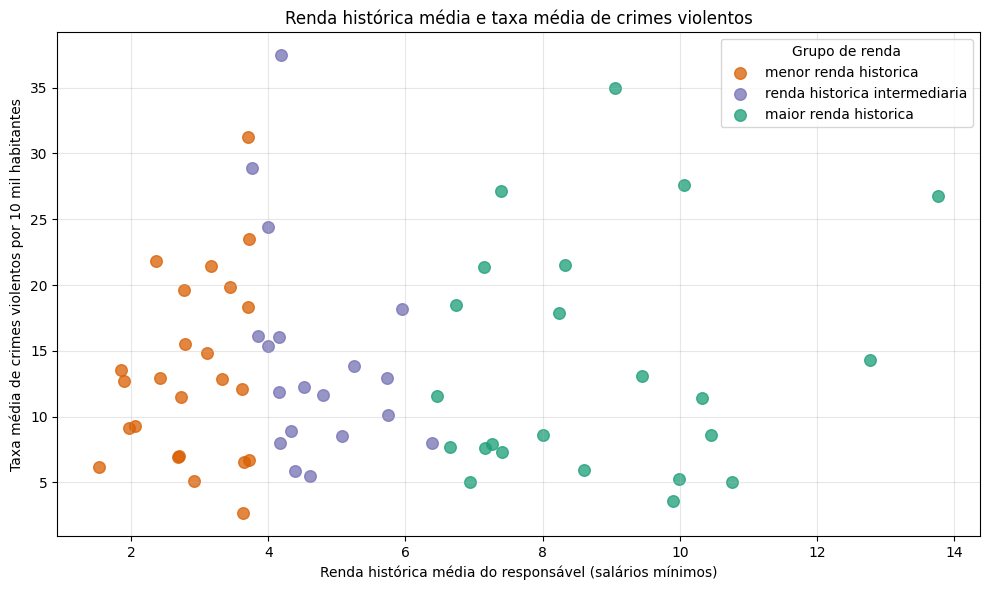

In [127]:
violencia_renda_todos_bairros_filtrado = (
    violencia_renda_todos_bairros[
        violencia_renda_todos_bairros["taxa_media_violencia_10k"] <= 40
    ]
    .copy()
)

plt.figure(figsize=(10, 6))

for grupo, dados_grupo in violencia_renda_todos_bairros_filtrado.groupby(
    "grupo_renda",
    observed=True
):
    plt.scatter(
        dados_grupo["renda_historica_media_sm"],
        dados_grupo["taxa_media_violencia_10k"],
        label=grupo,
        color=cores_grupo[str(grupo)],
        alpha=0.75,
        s=70
    )

plt.title("Renda histórica média e taxa média de crimes violentos")
plt.xlabel("Renda histórica média do responsável (salários mínimos)")
plt.ylabel("Taxa média de crimes violentos por 10 mil habitantes")
plt.legend(title="Grupo de renda")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    caminho_imagens / "renda_historica_media_e_taxa_media_de_crimes_violentos.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Mapa geográfico

In [128]:
violencia_mapa = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        total_ocorrencias=("total_ocorrencias", "sum"),
        total_violencia=("total_crime_violento", "sum"),
        taxa_media_violencia_10k=(
            "taxa_crime_violento_10k",
            "mean"
        ),
        anos_observados=("OCORRENCIA_ANO", "nunique")
    )
)

In [129]:
violencia_mapa["proporcao_violencia_pct"] = (
    violencia_mapa["total_violencia"]
    / violencia_mapa["total_ocorrencias"]
    * 100
)

violencia_mapa["bairro_join"] = (
    violencia_mapa["ATENDIMENTO_BAIRRO_NOME"]
    .apply(normalizar_bairro)
)

In [130]:
violencia_mapa = violencia_mapa.round(
    {
        "taxa_media_violencia_10k": 2,
        "proporcao_violencia_pct": 2,
    }
)

In [131]:
colunas_violencia = [
    "bairro_join",
    "ATENDIMENTO_BAIRRO_NOME",
    "total_violencia",
    "taxa_media_violencia_10k",
    "proporcao_violencia_pct",
]

gdf_violencia = gdf_bairros.merge(
    violencia_mapa[colunas_violencia],
    on="bairro_join",
    how="left",
    validate="one_to_one"
)

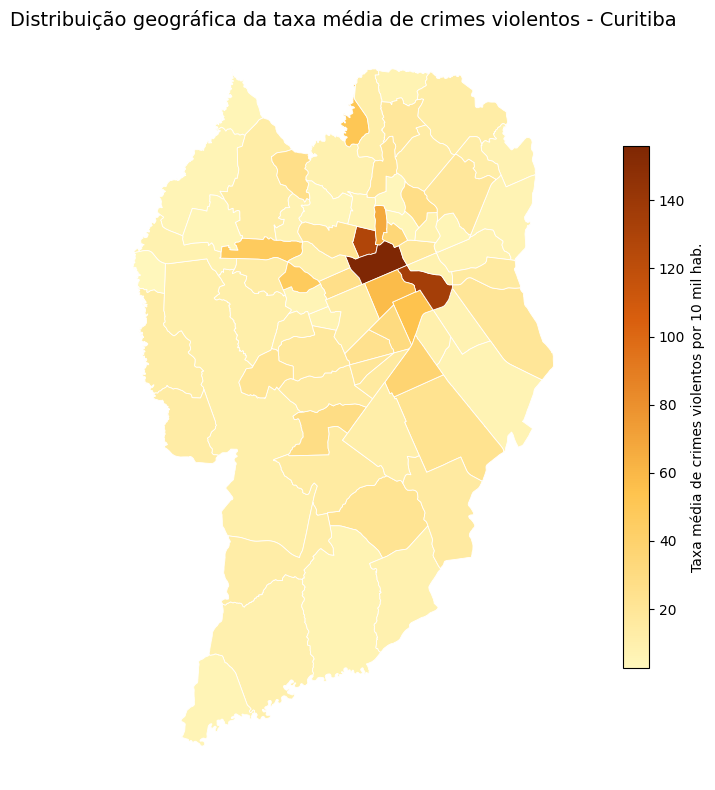

In [132]:
cmap_violencia = LinearSegmentedColormap.from_list(
    "violencia_amarelo_vermelho",
    ["#fff7bc", "#fec44f", "#d95f0e", "#7f2704"]
)

fig, ax = plt.subplots(figsize=(10, 8))

gdf_violencia.plot(
    column="taxa_media_violencia_10k",
    ax=ax,
    cmap=cmap_violencia,
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dado"
    },
    legend_kwds={
        "label": "Taxa média de crimes violentos por 10 mil hab.",
        "shrink": 0.7
    }
)

ax.set_title(
    "Distribuição geográfica da taxa média de crimes violentos - Curitiba",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

### 3.4 Relação entre renda histórica média e analfabetismo

Nessa seção, a relação entre renda e analfabetismo será observada por bairro. Para isso, calcularemos a taxa histórica média de analfabetismo da população de 15 anos ou mais.

In [133]:
coluna_analfabetismo = "pct_analfabetismo_15mais_estimado"

In [134]:
df_metricas[coluna_analfabetismo] = pd.to_numeric(
    df_metricas[coluna_analfabetismo].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

In [135]:
analfabetismo_renda_bairro = (
    df_metricas[df_metricas["OCORRENCIA_ANO"] < 2026]
    .groupby(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"], as_index=False)
    .agg(
        renda_media_ano_sm=(coluna_renda, "first"),
        pct_analfabetismo_ano=(coluna_analfabetismo, "first")
    )
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        renda_historica_media_sm=("renda_media_ano_sm", "mean"),
        pct_analfabetismo_historico_medio=("pct_analfabetismo_ano", "mean"),
        anos_observados=("OCORRENCIA_ANO", "nunique")
    )
    .dropna(subset=[
        "renda_historica_media_sm",
        "pct_analfabetismo_historico_medio"
    ])
    .round({
        "renda_historica_media_sm": 2,
        "pct_analfabetismo_historico_medio": 2
    })
)

In [136]:
correlacao_renda_analfabetismo = (
    analfabetismo_renda_bairro[
        ["renda_historica_media_sm", "pct_analfabetismo_historico_medio"]
    ]
    .corr()
    .loc["renda_historica_media_sm", "pct_analfabetismo_historico_medio"]
)

In [137]:
round(correlacao_renda_analfabetismo, 3)

np.float64(-0.727)

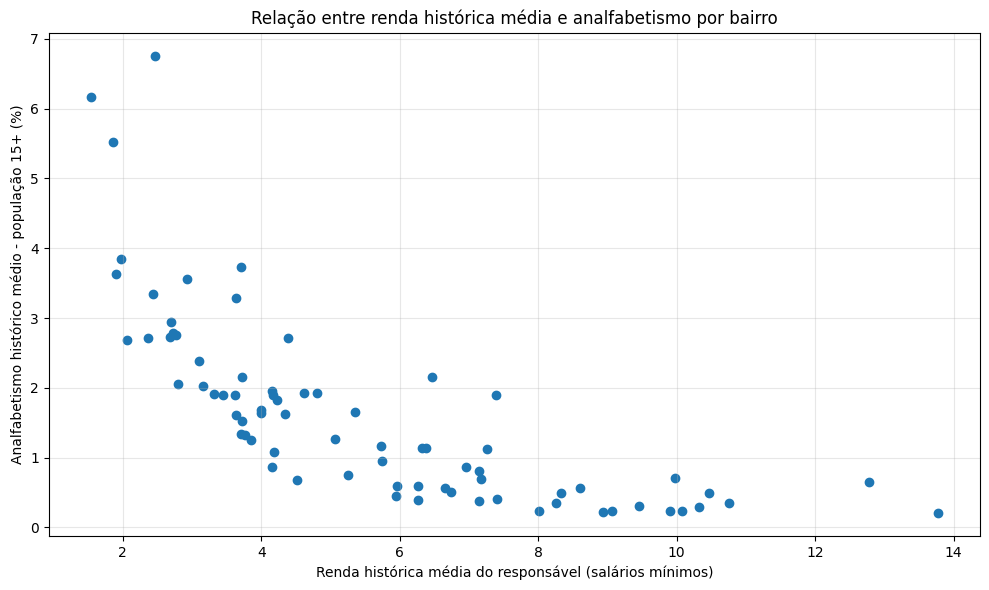

In [138]:
analfabetismo_renda_bairro.sort_values(
    "pct_analfabetismo_historico_medio",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.scatter(
    analfabetismo_renda_bairro["renda_historica_media_sm"],
    analfabetismo_renda_bairro["pct_analfabetismo_historico_medio"]
)

plt.title("Relação entre renda histórica média e analfabetismo por bairro")
plt.xlabel("Renda histórica média do responsável (salários mínimos)")
plt.ylabel("Analfabetismo histórico médio - população 15+ (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico indica uma relação negativa entre renda histórica média e analfabetismo: bairros com menor renda tendem a apresentar percentuais mais altos de analfabetismo entre a população de 15 anos ou mais. A concentração de pontos à esquerda e mais acima mostra que os maiores indicadores de analfabetismo aparecem nos bairros com renda média mais baixa. Já nos bairros com renda mais alta, os pontos ficam próximos da base do gráfico, indicando taxas de analfabetismo menores. Ainda, a relação não é perfeita, pois existem alguns bairros com renda intermediária ou alta que ainda apresentam valores um pouco acima do esperado.

### 3.5 Relação entre analfabetismo, alfabetização e ocorrências relacionadas a violência

Nessa seção, será testada a hipótese de que bairros com maior analfabetismo concetram mais ocorrências relacioandas a violência por 10 mil habitantes.

In [139]:
coluna_alfabetizacao = "pct_alfabetizacao_15mais_estimado"
coluna_analfabetismo = "pct_analfabetismo_15mais_estimado"

In [140]:
for coluna in [coluna_alfabetizacao, coluna_analfabetismo]:
    df_metricas[coluna] = pd.to_numeric(
        df_metricas[coluna].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

In [141]:
educacao_bairro = (
    df_metricas[df_metricas["OCORRENCIA_ANO"] < 2026]
    .groupby(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"], as_index=False)
    .agg(
        pct_alfabetizacao_ano=(coluna_alfabetizacao, "first"),
        pct_analfabetismo_ano=(coluna_analfabetismo, "first")
    )
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        pct_alfabetizacao_media=("pct_alfabetizacao_ano", "mean"),
        pct_analfabetismo_medio=("pct_analfabetismo_ano", "mean")
    )
)

In [142]:
violencia_bairro = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        total_crimes_violentos=("total_crime_violento", "sum"),
        taxa_media_violencia_10k=("taxa_crime_violento_10k", "mean")
    )
)

In [143]:
educacao_violencia_bairro = (
    educacao_bairro
    .merge(
        violencia_bairro,
        on="ATENDIMENTO_BAIRRO_NOME",
        how="inner"
    )
    .dropna()
    .round(2)
)


In [144]:
correlacoes_educacao_violencia = educacao_violencia_bairro[
    [
        "pct_analfabetismo_medio",
        "pct_alfabetizacao_media",
        "taxa_media_violencia_10k"
    ]
].corr(method="spearman")


In [145]:
correlacoes_educacao_violencia.loc[
    ["pct_analfabetismo_medio", "pct_alfabetizacao_media"],
    ["taxa_media_violencia_10k"]
].round(3)

,taxa_media_violencia_10k
pct_analfabetismo_medio,-0.161
pct_alfabetizacao_media,0.161


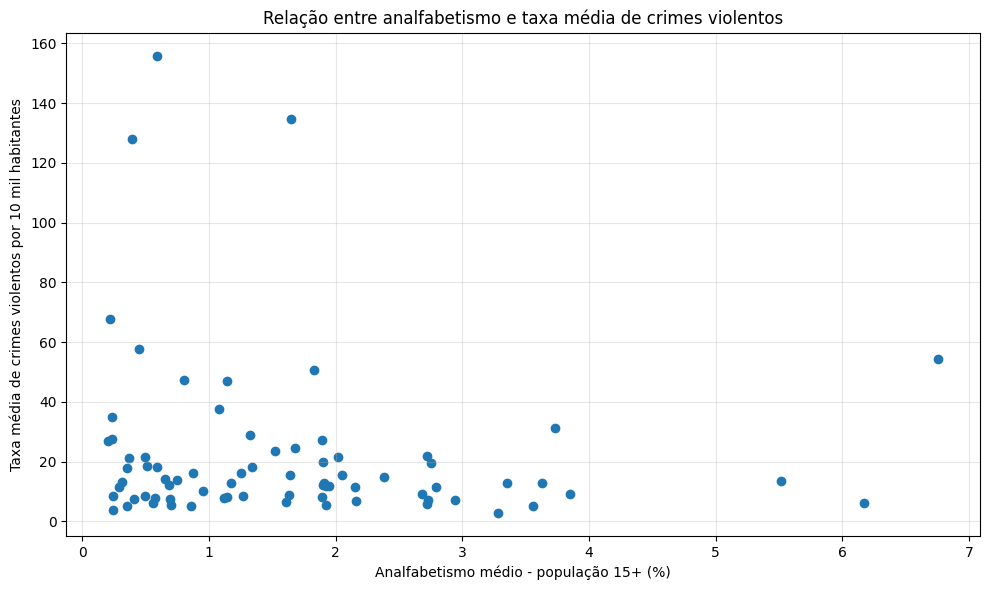

In [146]:
plt.figure(figsize=(10, 6))

plt.scatter(
    educacao_violencia_bairro["pct_analfabetismo_medio"],
    educacao_violencia_bairro["taxa_media_violencia_10k"]
)

plt.title("Relação entre analfabetismo e taxa média de crimes violentos")
plt.xlabel("Analfabetismo médio - população 15+ (%)")
plt.ylabel("Taxa média de crimes violentos por 10 mil habitantes")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [147]:
n_bairros = 10

comparacao_grupos_educacao_violencia = pd.concat(
    [
        educacao_violencia_bairro
        .nlargest(n_bairros, "pct_analfabetismo_medio")
        .assign(grupo="maior analfabetismo"),

        educacao_violencia_bairro
        .nlargest(n_bairros, "pct_alfabetizacao_media")
        .assign(grupo="maior alfabetizacao")
    ],
    ignore_index=True
)

comparacao_grupos_educacao_violencia.groupby("grupo", as_index=False).agg(
    media_total_crimes_violentos=("total_crimes_violentos", "mean"),
    media_taxa_violencia_10k=("taxa_media_violencia_10k", "mean")
).round(2)

,grupo,media_total_crimes_violentos,media_taxa_violencia_10k
0,maior alfabetizacao,422.3,21.69
1,maior analfabetismo,302.1,15.5


Os resultados indicam que o analfabetismo médio não está associado ao aumento da taxa de crimes violentos. A correlação é frace e negativa, sugerindo uma tendência muito pequena de bairros com maior analfabetismo apreesentarem menores taxas de violência, mas essa relação é frágil. 

Além disso, os bairros com maior alfabetização tiver média maior de cries violentos (422.3) e também maior taxa média por 10 mil habitantes (21.69) do que os bairros com maior analfabetismo. Assim, para esses dados, a violência parece estar mais relacionada a outra fatores urbanos.

In [148]:
coluna_alfabetizacao = "pct_alfabetizacao_15mais_estimado"

In [149]:
df_metricas[coluna_alfabetizacao] = pd.to_numeric(
      df_metricas[coluna_alfabetizacao].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

In [150]:
alfabetizacao_historica_todos_bairros = (
    df_metricas[df_metricas["OCORRENCIA_ANO"] < 2026]
    .groupby(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"], as_index=False)
    .agg(pct_alfabetizacao_ano=(coluna_alfabetizacao, "first"))
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        pct_alfabetizacao_historica_media=("pct_alfabetizacao_ano", "mean"),
        anos_alfabetizacao_observados=("OCORRENCIA_ANO", "nunique")
    )
    .dropna(subset=["pct_alfabetizacao_historica_media"])
)

In [151]:
violencia_alfabetizacao_todos_bairros = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        taxa_media_violencia_10k=("taxa_crime_violento_10k", "mean")
    )
    .merge(
        alfabetizacao_historica_todos_bairros[
            [
                "ATENDIMENTO_BAIRRO_NOME",
                "pct_alfabetizacao_historica_media"
            ]
        ],
        on="ATENDIMENTO_BAIRRO_NOME",
        how="inner"
    )
    .dropna()
)

In [152]:
q1 = violencia_alfabetizacao_todos_bairros["pct_alfabetizacao_historica_media"].quantile(1/3)
q2 = violencia_alfabetizacao_todos_bairros["pct_alfabetizacao_historica_media"].quantile(2/3)

In [153]:
violencia_alfabetizacao_todos_bairros["grupo_alfabetizacao"] = pd.cut(

violencia_alfabetizacao_todos_bairros["pct_alfabetizacao_historica_media"],
    bins=[
        -float("inf"),
        q1,
        q2,
        float("inf")
    ],
    labels=[
        "menor alfabetizacao",
        "alfabetizacao intermediaria",
        "maior alfabetizacao"
    ]
)

In [154]:
violencia_alfabetizacao_todos_bairros_filtrado = (
    violencia_alfabetizacao_todos_bairros[violencia_alfabetizacao_todos_bairros["taxa_media_violencia_10k"] < 40].copy()
)

In [155]:
cores_grupo_alfabetizacao = {
    "menor alfabetizacao": "#d95f02",
    "alfabetizacao intermediaria": "#7570b3",
    "maior alfabetizacao": "#1b9e77",
}

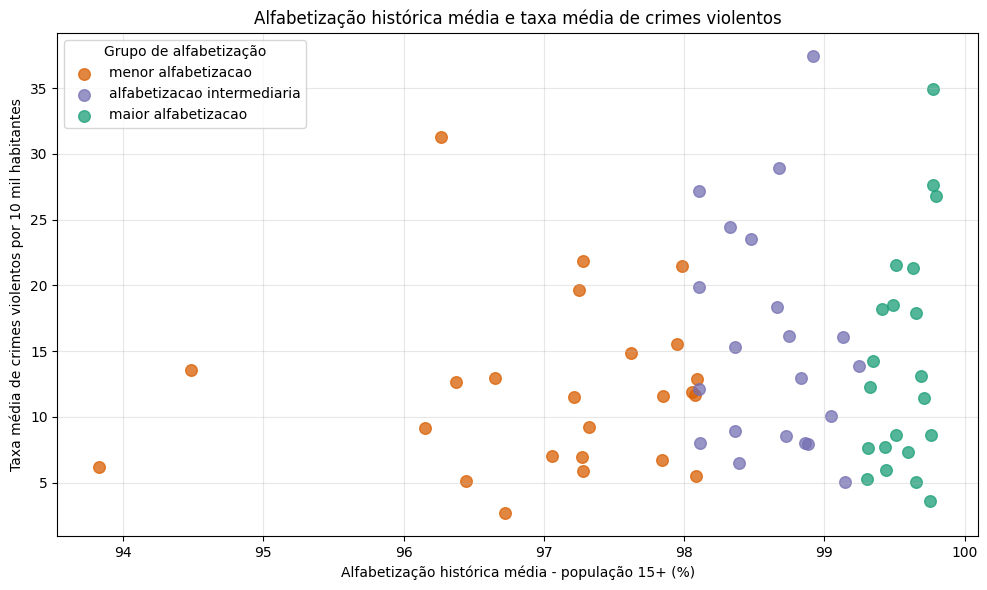

In [156]:
plt.figure(figsize=(10, 6))

for grupo, dados_grupo in violencia_alfabetizacao_todos_bairros_filtrado.groupby(
    "grupo_alfabetizacao",observed=True):
    plt.scatter(
        dados_grupo["pct_alfabetizacao_historica_media"],
        dados_grupo["taxa_media_violencia_10k"],
        label=grupo,
        color=cores_grupo_alfabetizacao[str(grupo)],
        alpha=0.75,
        s=70
    )

plt.title("Alfabetização histórica média e taxa média de crimes violentos")
plt.xlabel("Alfabetização histórica média - população 15+ (%)")
plt.ylabel("Taxa média de crimes violentos por 10 mil habitantes")
plt.legend(title="Grupo de alfabetização")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    caminho_imagens / "alfabetizacao_historica_media_e_taxa_media_de_crimes_violentos.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### 3.6 Relação entre analfabetismo, alfabetização e ocorrências relacionadas a drogas/substâncias

Nessa seção, será testada a hipótese de que bairros com maior analfabetismo concetram mais ocorrências relacioandas a drogas/substâncias por 10 mil habitantes.


In [157]:
coluna_alfabetizacao = "pct_alfabetizacao_15mais_estimado"
coluna_analfabetismo = "pct_analfabetismo_15mais_estimado"

In [158]:
for coluna in [coluna_alfabetizacao, coluna_analfabetismo]:
    df_metricas[coluna] = pd.to_numeric(
        df_metricas[coluna].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

educacao_bairro = (
    df_metricas[df_metricas["OCORRENCIA_ANO"] < 2026]
    .groupby(["ATENDIMENTO_BAIRRO_NOME", "OCORRENCIA_ANO"], as_index=False)
    .agg(
        pct_alfabetizacao_ano=(coluna_alfabetizacao, "first"),
        pct_analfabetismo_ano=(coluna_analfabetismo, "first")
    )
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        pct_alfabetizacao_media=("pct_alfabetizacao_ano", "mean"),
        pct_analfabetismo_medio=("pct_analfabetismo_ano", "mean")
    )
)


In [159]:
drogas_bairro = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        total_drogas_substancias=("total_crime_drogas_substancias", "sum"),
        taxa_media_drogas_substancias_10k=(
            "taxa_crime_drogas_substancias_10k",
            "mean"
        )
    )
)

In [160]:
educacao_drogas_bairro = (
    educacao_bairro
    .merge(
        drogas_bairro,
        on="ATENDIMENTO_BAIRRO_NOME",
        how="inner"
    )
    .dropna()
    .round(2)
)

In [161]:
correlacoes_educacao_drogas = educacao_drogas_bairro[
    [
        "pct_analfabetismo_medio",
        "pct_alfabetizacao_media",
        "taxa_media_drogas_substancias_10k"
    ]
].corr(method="spearman")

correlacoes_educacao_drogas.loc[
    ["pct_analfabetismo_medio", "pct_alfabetizacao_media"],
    ["taxa_media_drogas_substancias_10k"]
].round(3)

,taxa_media_drogas_substancias_10k
pct_analfabetismo_medio,-0.431
pct_alfabetizacao_media,0.431


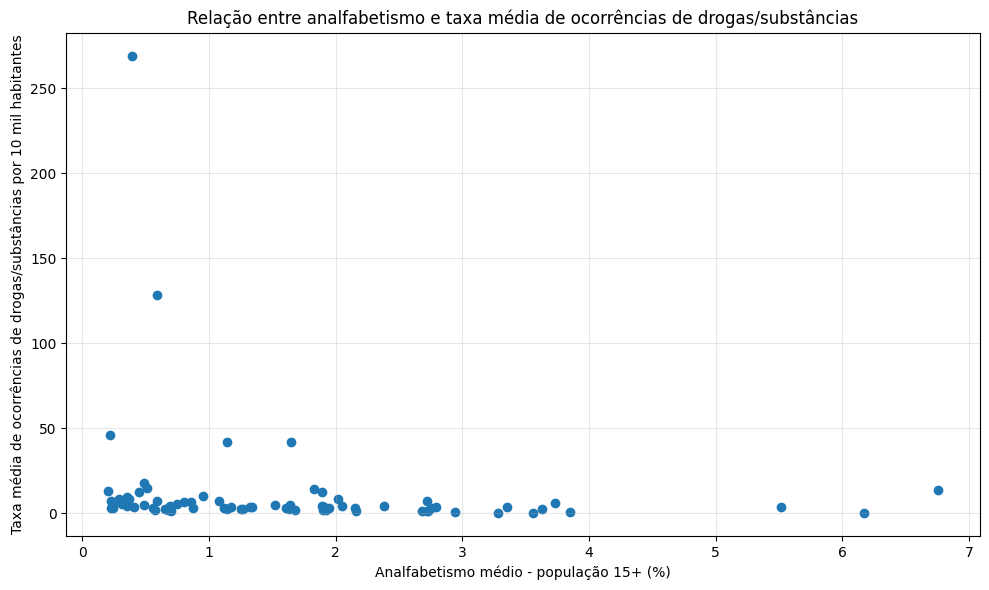

In [162]:
plt.figure(figsize=(10, 6))

plt.scatter(
    educacao_drogas_bairro["pct_analfabetismo_medio"],
    educacao_drogas_bairro["taxa_media_drogas_substancias_10k"]
)

plt.title("Relação entre analfabetismo e taxa média de ocorrências de drogas/substâncias")
plt.xlabel("Analfabetismo médio - população 15+ (%)")
plt.ylabel("Taxa média de ocorrências de drogas/substâncias por 10 mil habitantes")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [163]:
n_bairros = 10

comparacao_grupos_educacao_drogas = pd.concat(
    [
        educacao_drogas_bairro
        .nlargest(n_bairros, "pct_analfabetismo_medio")
        .assign(grupo="maior analfabetismo"),

        educacao_drogas_bairro
        .nlargest(n_bairros, "pct_alfabetizacao_media")
        .assign(grupo="maior alfabetizacao")
    ],
    ignore_index=True
)

comparacao_grupos_educacao_drogas.groupby("grupo", as_index=False).agg(
    media_total_drogas_substancias=("total_drogas_substancias", "mean"),
    media_taxa_drogas_substancias_10k=(
        "taxa_media_drogas_substancias_10k",
        "mean"
    )
).round(2)

,grupo,media_total_drogas_substancias,media_taxa_drogas_substancias_10k
0,maior alfabetizacao,190.0,10.42
1,maior analfabetismo,61.2,3.27


Os dados possuemuma relação negativa moderada entre analfabetismo e ocorrências de drogas/substâncias por 10 mil habitantes. A correlação de -0.431 sugere que bairros com maior analfabetismo tendem a apresentar menores taxas desse tipo de ocorrência, enquanto bairros com maior alfabetização tendem a apresentar taxas maiores. 

A comparação por grupo mostra que bairros com maior alfabetização tiveram média de 190 ocorrências e taxa média de 10.42 por 10 mil habitantes, enquanto bairros com maior analfabetismo tiveram média de 61.2 ocorrências e taxa de 3.27 por 10 mil habitantes.

In [164]:
drogas_alfabetizacao_todos_bairros = (
    metricas_bairro_ano[metricas_bairro_ano["OCORRENCIA_ANO"] < 2026]
    .groupby("ATENDIMENTO_BAIRRO_NOME", as_index=False)
    .agg(
        taxa_media_drogas_substancias_10k=(
            "taxa_crime_drogas_substancias_10k",
            "mean"
        )
    )
    .merge(
        alfabetizacao_historica_todos_bairros[
            [
                "ATENDIMENTO_BAIRRO_NOME",
                "pct_alfabetizacao_historica_media"
            ]
        ],
        on="ATENDIMENTO_BAIRRO_NOME",
        how="inner"
    )
    .dropna()
)

In [165]:
q1 = drogas_alfabetizacao_todos_bairros["pct_alfabetizacao_historica_media"].quantile(1/3)
q2 = drogas_alfabetizacao_todos_bairros["pct_alfabetizacao_historica_media"].quantile(2/3)

In [166]:
drogas_alfabetizacao_todos_bairros["grupo_alfabetizacao"] = pd.cut(
    drogas_alfabetizacao_todos_bairros["pct_alfabetizacao_historica_media"],
    bins=[
        -float("inf"),
        q1,
        q2,
        float("inf")
    ],
    labels=[
        "menor alfabetizacao",
        "alfabetizacao intermediaria",
        "maior alfabetizacao"
    ]
)

In [167]:
drogas_alfabetizacao_todos_bairros_filtrado = (
    drogas_alfabetizacao_todos_bairros[drogas_alfabetizacao_todos_bairros["taxa_media_drogas_substancias_10k"] < 40].copy()
)

In [168]:
cores_grupo_alfabetizacao = {
    "menor alfabetizacao": "#d95f02",
    "alfabetizacao intermediaria": "#7570b3",
    "maior alfabetizacao": "#1b9e77",
}

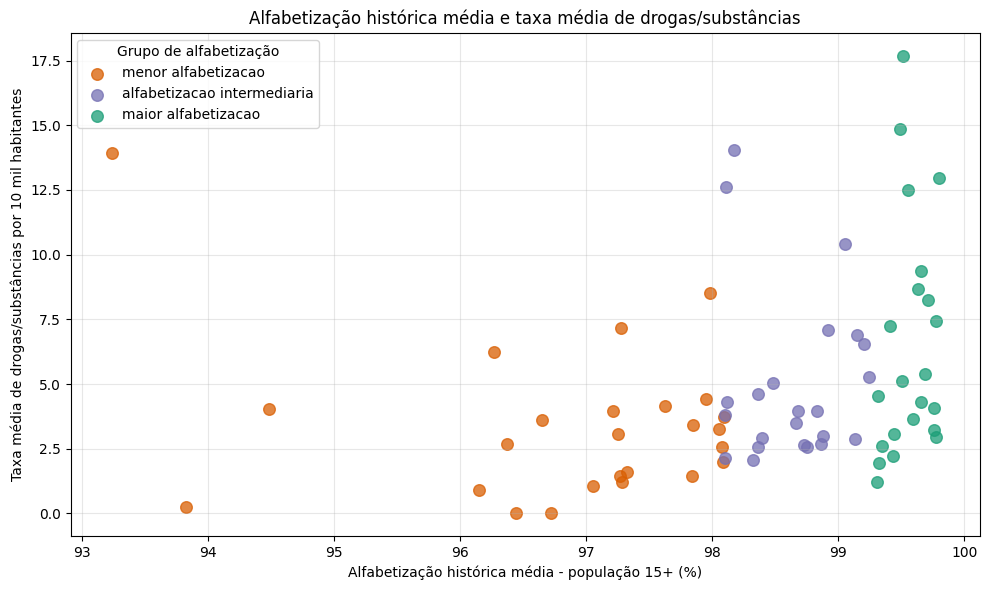

In [169]:
plt.figure(figsize=(10, 6))

for grupo, dados_grupo in drogas_alfabetizacao_todos_bairros_filtrado.groupby(
    "grupo_alfabetizacao",
    observed=True):
    plt.scatter(
        dados_grupo["pct_alfabetizacao_historica_media"],
        dados_grupo["taxa_media_drogas_substancias_10k"],
        label=grupo,
        color=cores_grupo_alfabetizacao[str(grupo)],
        alpha=0.75,
        s=70
    )

plt.title("Alfabetização histórica média e taxa média de drogas/substâncias")
plt.xlabel("Alfabetização histórica média - população 15+ (%)")
plt.ylabel("Taxa média de drogas/substâncias por 10 mil habitantes")
plt.legend(title="Grupo de alfabetização")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    caminho_imagens / "alfabetizacao_historica_media_e_taxa_media_de_crimes_drogas.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 4. A proporção de flagrantes varia com o tipo de ocorrência?

In [170]:
df_flagrante_tipo = df_metricas.copy()

In [171]:
df_flagrante_tipo["FLAG_FLAGRANTE"] = pd.to_numeric(
    df_flagrante_tipo["FLAG_FLAGRANTE"],
    errors="coerce"
).fillna(0).astype(int)

for coluna in colunas_tipo_ocorrencia:
    df_flagrante_tipo[coluna] = pd.to_numeric(
        df_flagrante_tipo[coluna],
        errors="coerce"
    ).fillna(0).astype(int)

df_flagrante_tipo["OCORRENCIA_ANO"] = pd.to_numeric(
    df_flagrante_tipo["OCORRENCIA_ANO"],
    errors="coerce"
).astype("Int64")

df_flagrante_tipo = df_flagrante_tipo[
    df_flagrante_tipo["OCORRENCIA_ANO"] < 2026
].copy()

In [172]:
flagrantes_por_tipo = (
    df_flagrante_tipo
    .melt(
        id_vars=["FLAG_FLAGRANTE"],
        value_vars=colunas_tipo_ocorrencia,
        var_name="tipo_ocorrencia",
        value_name="ocorrencia_tipo"
    )
    .query("ocorrencia_tipo == 1")
    .groupby("tipo_ocorrencia", as_index=False)
    .agg(
        total_ocorrencias=("ocorrencia_tipo", "sum"),
        total_flagrantes=("FLAG_FLAGRANTE", "sum")
    )
)

flagrantes_por_tipo["proporcao_flagrantes_pct"] = (
    flagrantes_por_tipo["total_flagrantes"]
    / flagrantes_por_tipo["total_ocorrencias"]
    * 100
)

flagrantes_por_tipo = (
    flagrantes_por_tipo
    .assign(
        tipo_ocorrencia_formatado=lambda df: (
            df["tipo_ocorrencia"]
            .str.lower()
            .str.replace("_", " ")
        )
    )
    .sort_values("proporcao_flagrantes_pct", ascending=False)
    .round({"proporcao_flagrantes_pct": 2})
)

In [173]:
flagrantes_por_tipo

,tipo_ocorrencia,total_ocorrencias,total_flagrantes,proporcao_flagrantes_pct,tipo_ocorrencia_formatado
3,CRIME_ADMINISTRACAO_PUBLICA,2637,1352,51.27,crime administracao publica
7,CRIME_HONRA_DISCRIMINACAO,247,92,37.25,crime honra discriminacao
5,CRIME_DROGAS_SUBSTANCIAS,24868,4437,17.84,crime drogas substancias
10,CRIME_VIOLENTO,57589,7220,12.54,crime violento
6,CRIME_FRAUDE_DOCUMENTAL,1050,110,10.48,crime fraude documental
4,CRIME_CRIANCA_ADOLESCENTE,350,23,6.57,crime crianca adolescente
9,CRIME_PATRIMONIAL,73417,4441,6.05,crime patrimonial
8,CRIME_ORDEM_PUBLICA,40906,792,1.94,crime ordem publica
2,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,231580,4483,1.94,atendimento operacional assistencial
1,ACIDENTE_TRANSITO,108099,1113,1.03,acidente transito


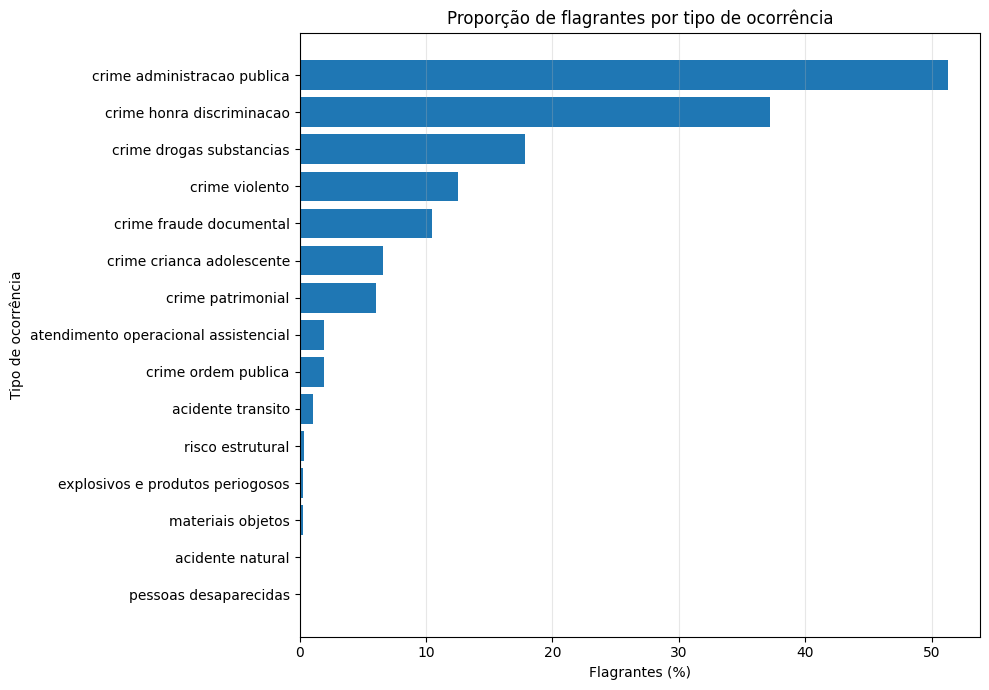

In [174]:
dados_plot = flagrantes_por_tipo.sort_values(
    "proporcao_flagrantes_pct",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    dados_plot["tipo_ocorrencia_formatado"],
    dados_plot["proporcao_flagrantes_pct"]
)

plt.title("Proporção de flagrantes por tipo de ocorrência")
plt.xlabel("Flagrantes (%)")
plt.ylabel("Tipo de ocorrência")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Matriz de correlação

Vamos calcular a matriz de correlação para as colunas:

- `FLAG_FLAGRANTE`;
- `MADRUGADA`;
- `MANHA`;
- `TARDE`;
- `NOITE`;
- `CRIME_VIOLENTO`;
- `CRIME_PATRIMONIAL`;
- `CRIME_DROGAS_SUBSTANCIAS`;
- `CRIME_ORDEM_PUBLICA`;
- `populacao_estimado`;
- `rendimento_medio_responsavel_sm_estimado`
- `pct_alfabetizacao_15mais_estimado`;
- `pct_analfabetizacao_15mais_estimado`.

Usaremos a correlação de Spearman porque ela é mais adequada para medir relações monotônicas entre variáveis, sem assumir que a relação seja linear ou que os dados tenham distribuição normal.

Matematicamente, a correlação ed Spearman mede a associação entre os postos (ranks) das variáveis:

$$
\rho = 1 - \frac{6 \sum d_{i}^2}{n(n^2 - 1)}
$$

onde $d_i$ é a deifença entre os ranks de cada observação.

A interpretação é:

- se uma variável tende a aumentar quando a outra aumenta: correlação positiva;
- se uma tende a diminuir quando a outra aumenta: correlação negativa;
- próximo de 0: pouca associação monotônica.

In [175]:
colunas = {
    "FLAG_FLAGRANTE": "Flagrante",
    "MADRUGADA": "Madrugada",
    "MANHA": "Manhã",
    "TARDE": "Tarde",
    "NOITE": "Noite",
    "CRIME_VIOLENTO": "Crime violento",
    "CRIME_PATRIMONIAL": "Crime patrimonial",
    "CRIME_DROGAS_SUBSTANCIAS": "Drogas/substâncias",
    "CRIME_ORDEM_PUBLICA": "Ordem pública",
    "populacao_estimado": "População",
    "rendimento_medio_responsavel_sm_estimado": "Renda",
    "pct_alfabetizacao_15mais_estimado": "Alfabetização",
    "pct_analfabetismo_15mais_estimado": "Analfabetismo",
}

In [176]:
df_corr = df_metricas.copy()

In [177]:
df_corr = df_corr.merge(
    renda_historica_bairro[
        [
            "ATENDIMENTO_BAIRRO_NOME",
            "log_renda_historica_media_sm"
        ]
    ],
    on="ATENDIMENTO_BAIRRO_NOME",
    how="left"
)

In [178]:
df_corr = (
    df_corr[list(colunas)]
    .replace(",", ".", regex=True)
    .apply(pd.to_numeric, errors="coerce")
)

df_corr = df_corr.loc[:, df_corr.nunique(dropna=True) > 1]

In [179]:
matriz_corr = df_corr.corr(method="spearman")

In [180]:
rotulos = [colunas[col] for col in matriz_corr.columns]

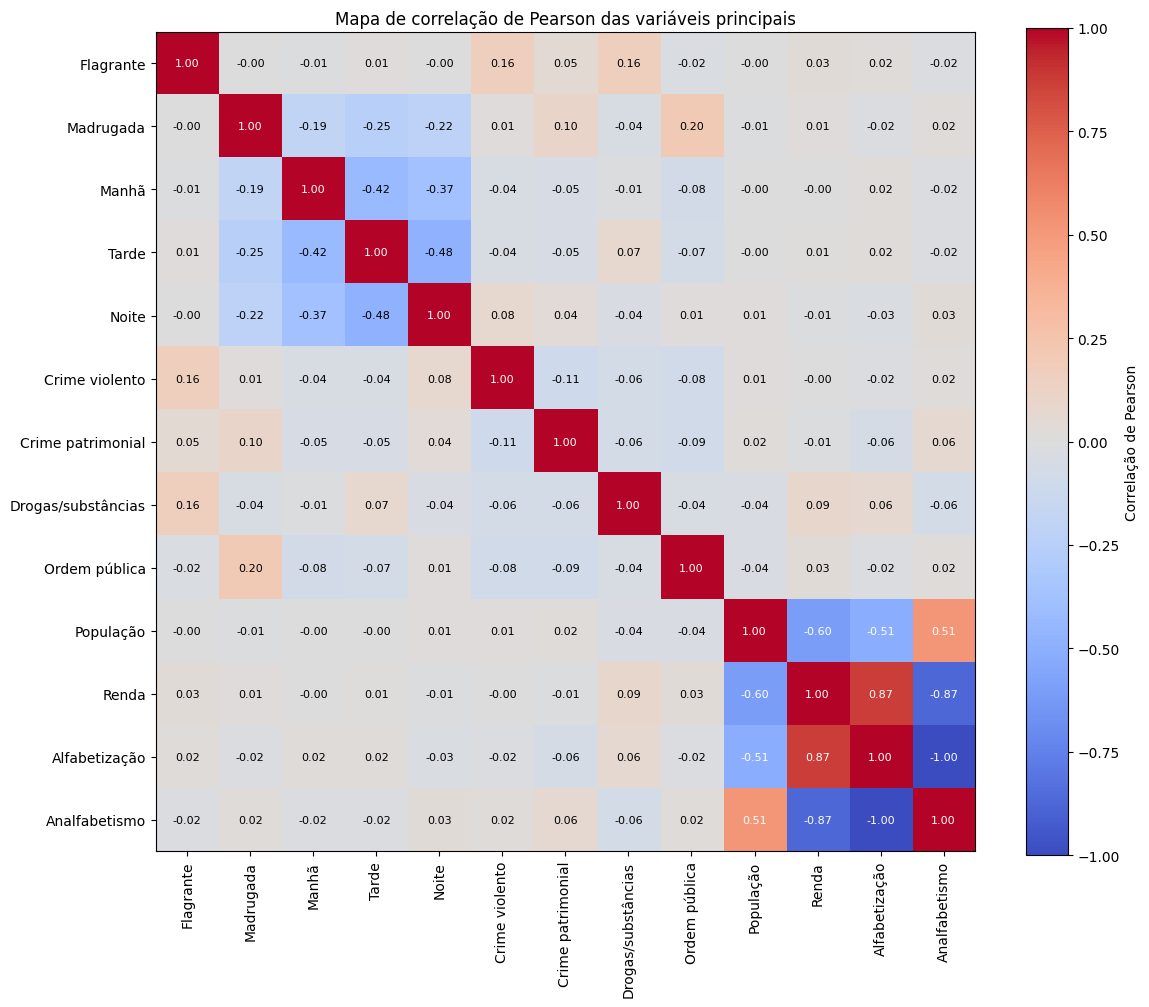

In [181]:
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    matriz_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(rotulos)))
ax.set_yticks(range(len(rotulos)))

ax.set_xticklabels(rotulos, rotation=90)
ax.set_yticklabels(rotulos)

for i in range(len(matriz_corr)):
    for j in range(len(matriz_corr)):
        valor = matriz_corr.iloc[i, j]

        if pd.notna(valor):
            ax.text(
                j,
                i,
                f"{valor:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(valor) >= 0.5 else "black"
            )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlação de Pearson")

plt.title("Mapa de correlação de Pearson das variáveis principais")
plt.tight_layout()
plt.show()

### 6. Outliers de ocorrência

In [182]:
colunas_tipo_ocorrencia = [
    "CRIME_VIOLENTO",
    "ATENDIMENTO_OPERACIONAL_ASSISTENCIAL",
    "ACIDENTE_TRANSITO",
    "ACIDENTE_NATURAL",
    "CRIME_PATRIMONIAL",
    "CRIME_ADMINISTRACAO_PUBLICA",
    "CRIME_HONRA_DISCRIMINACAO",
    "CRIME_CRIANCA_ADOLESCENTE",
    "CRIME_FRAUDE_DOCUMENTAL",
    "CRIME_DROGAS_SUBSTANCIAS",
    "CRIME_ORDEM_PUBLICA",
    "RISCO_ESTRUTURAL",
    "EXPLOSIVOS_E_PRODUTOS_PERIOGOSOS",
    "PESSOAS_DESAPARECIDAS",
    "MATERIAIS_OBJETOS",
]

In [183]:
df_percentual_tipos = df_metricas.copy()

for coluna in colunas_tipo_ocorrencia:
    df_percentual_tipos[coluna] = pd.to_numeric(
        df_percentual_tipos[coluna],
        errors="coerce"
    ).fillna(0).astype(int)

percentual_tipos_ocorrencia = (
    df_percentual_tipos[colunas_tipo_ocorrencia]
    .sum()
    .reset_index()
    .rename(columns={
        "index": "tipo_ocorrencia",
        0: "total_ocorrencias"
    })
)

In [184]:
percentual_tipos_ocorrencia["percentual_registros"] = (
    percentual_tipos_ocorrencia["total_ocorrencias"]
    / len(df_percentual_tipos)
    * 100
)

percentual_tipos_ocorrencia = (
    percentual_tipos_ocorrencia
    .sort_values("percentual_registros")
    .round({"percentual_registros": 2})
    .reset_index(drop=True)
)

In [185]:
percentual_tipos_ocorrencia

,tipo_ocorrencia,total_ocorrencias,percentual_registros
0,CRIME_HONRA_DISCRIMINACAO,254,0.04
1,CRIME_CRIANCA_ADOLESCENTE,353,0.06
2,CRIME_FRAUDE_DOCUMENTAL,1066,0.17
3,PESSOAS_DESAPARECIDAS,1526,0.25
4,CRIME_ADMINISTRACAO_PUBLICA,2660,0.44
5,MATERIAIS_OBJETOS,5471,0.90
6,EXPLOSIVOS_E_PRODUTOS_PERIOGOSOS,7416,1.22
7,RISCO_ESTRUTURAL,9992,1.64
8,ACIDENTE_NATURAL,19164,3.14
9,CRIME_DROGAS_SUBSTANCIAS,25189,4.13


In [186]:
outliers_baixa_quantidade = percentual_tipos_ocorrencia[
      percentual_tipos_ocorrencia["percentual_registros"] < 1
  ]

In [187]:
outliers_baixa_quantidade

,tipo_ocorrencia,total_ocorrencias,percentual_registros
0,CRIME_HONRA_DISCRIMINACAO,254,0.04
1,CRIME_CRIANCA_ADOLESCENTE,353,0.06
2,CRIME_FRAUDE_DOCUMENTAL,1066,0.17
3,PESSOAS_DESAPARECIDAS,1526,0.25
4,CRIME_ADMINISTRACAO_PUBLICA,2660,0.44
5,MATERIAIS_OBJETOS,5471,0.90


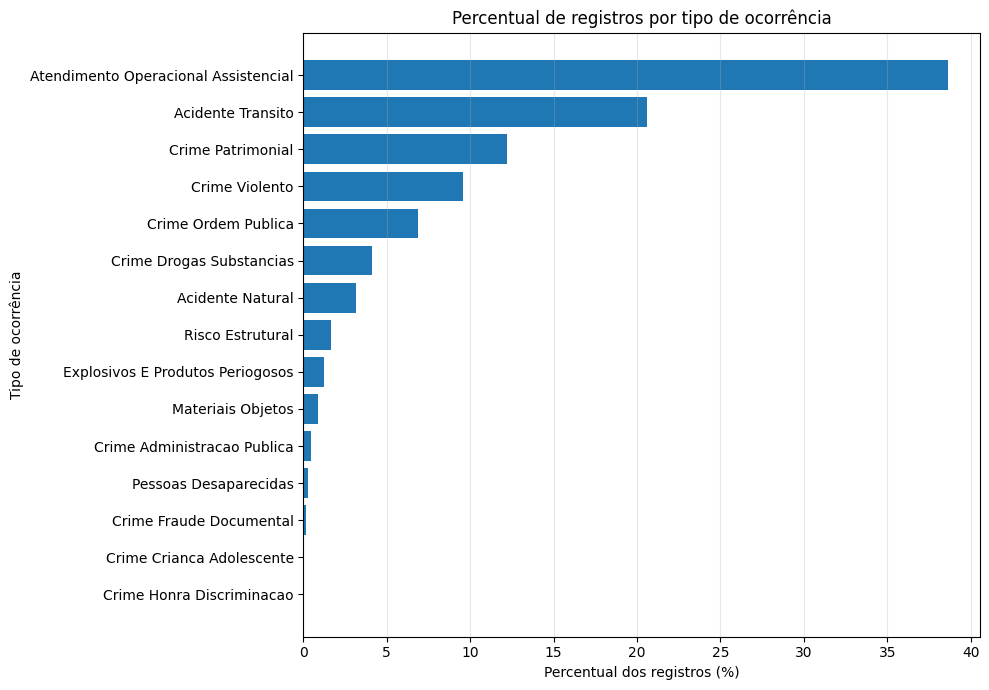

In [188]:
dados_plot = percentual_tipos_ocorrencia.copy()

dados_plot["tipo_ocorrencia_formatado"] = (
    dados_plot["tipo_ocorrencia"]
    .str.lower()
    .str.replace("_", " ")
    .str.title()
)

plt.figure(figsize=(10, 7))

plt.barh(
    dados_plot["tipo_ocorrencia_formatado"],
    dados_plot["percentual_registros"]
)

plt.title("Percentual de registros por tipo de ocorrência")
plt.xlabel("Percentual dos registros (%)")
plt.ylabel("Tipo de ocorrência")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()